<a href="https://colab.research.google.com/github/JPAmewu/My_Capstone_1_Imperial/blob/main/Week_13/02_Notebook/Week_10_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For each function for Week_10, I will follow this sequence:
1. Create week_10_dataset
2. Extract function
3. Check shapes and missing values
4. Calculate summary statistics
5. Plot the output trend
6. Plot the best-so-far trend
7. Identify the best query point
8. Plot the correlation heatmap
9. Plot each input against the output
10. Fit a Gaussian Process surrogate
11. Apply UCB to generate the next query point

In [ ]:
# 1. Unzip the Week 9 dataset

import os
import shutil
import zipfile

import numpy as np

zip_path = "/content/week_9_dataset.zip"
extract_path = "/content/week_9_dataset"

# Remove an old extracted copy, if present.
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Week 9 dataset extracted successfully.")


In [52]:
# 2. Check the extracted .npy files

for root, folders, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".npy"):
            print(os.path.join(root, file))

/content/week_9_dataset/week_9_dataset/function_6_outputs.npy
/content/week_9_dataset/week_9_dataset/function_4_inputs.npy
/content/week_9_dataset/week_9_dataset/function_5_inputs.npy
/content/week_9_dataset/week_9_dataset/function_7_outputs.npy
/content/week_9_dataset/week_9_dataset/function_4_outputs.npy
/content/week_9_dataset/week_9_dataset/function_7_inputs.npy
/content/week_9_dataset/week_9_dataset/function_2_outputs.npy
/content/week_9_dataset/week_9_dataset/function_3_outputs.npy
/content/week_9_dataset/week_9_dataset/function_1_outputs.npy
/content/week_9_dataset/week_9_dataset/function_3_inputs.npy
/content/week_9_dataset/week_9_dataset/function_8_outputs.npy
/content/week_9_dataset/week_9_dataset/function_5_outputs.npy
/content/week_9_dataset/week_9_dataset/function_6_inputs.npy
/content/week_9_dataset/week_9_dataset/function_2_inputs.npy
/content/week_9_dataset/week_9_dataset/function_8_inputs.npy
/content/week_9_dataset/week_9_dataset/function_1_inputs.npy


In [ ]:
# 3. Load and validate the Week 9 dataset

EXPECTED_DIMENSIONS = {
    1: 2,
    2: 2,
    3: 3,
    4: 4,
    5: 4,
    6: 5,
    7: 6,
    8: 8,
}


def find_npy_file(folder, function_number, data_type):
    """Return the unique input or output array for a function."""
    if data_type not in {"input", "output"}:
        raise ValueError("data_type must be 'input' or 'output'.")

    expected_name = f"function_{function_number}_{data_type}s.npy"
    matching_files = sorted(
        os.path.join(root, filename)
        for root, _, files in os.walk(folder)
        for filename in files
        if filename.lower() == expected_name
    )

    if not matching_files:
        raise FileNotFoundError(
            f"No exact {data_type} file found for Function "
            f"{function_number}: {expected_name}"
        )

    if len(matching_files) > 1:
        raise RuntimeError(
            f"Multiple {data_type} files found for Function "
            f"{function_number}: {matching_files}"
        )

    return matching_files[0]


week_9_X = {}
week_9_y = {}

for function_number in range(1, 9):
    input_file = find_npy_file(
        extract_path,
        function_number,
        "input",
    )
    output_file = find_npy_file(
        extract_path,
        function_number,
        "output",
    )

    expected_dimension = EXPECTED_DIMENSIONS[function_number]
    inputs = np.asarray(np.load(input_file), dtype=float)
    outputs = np.asarray(np.load(output_file), dtype=float).reshape(-1, 1)

    if inputs.ndim == 1:
        if inputs.size % expected_dimension:
            raise ValueError(
                f"Function {function_number}: {inputs.size} input values "
                f"cannot be reshaped to dimension {expected_dimension}."
            )
        inputs = inputs.reshape(-1, expected_dimension)

    if inputs.ndim != 2 or inputs.shape[1] != expected_dimension:
        raise ValueError(
            f"Function {function_number}: expected a two-dimensional input "
            f"array with {expected_dimension} columns, got {inputs.shape}."
        )

    if not np.isfinite(inputs).all() or not np.isfinite(outputs).all():
        raise ValueError(
            f"Function {function_number}: input or output contains "
            "non-finite values."
        )

    week_9_X[function_number] = inputs
    week_9_y[function_number] = outputs

    print(f"Function {function_number}")
    print("Input shape :", inputs.shape)
    print("Output shape:", outputs.shape)
    print("-" * 40)


In [ ]:
# Validate input-output alignment without modifying the raw dataset.

for function_number in range(1, 9):
    input_rows = week_9_X[function_number].shape[0]
    output_rows = week_9_y[function_number].shape[0]

    if input_rows != output_rows:
        raise ValueError(
            f"Function {function_number}: found {input_rows} input rows and "
            f"{output_rows} outputs. Resolve the mismatch against the original "
            "query history before creating the Week 10 dataset."
        )

print("All Week 9 input and output arrays are aligned.")


In [ ]:
# Raw Week 9 files remain unchanged.
print("Validation complete; no source dataset files were overwritten.")


In [ ]:
new_X = {
    1: np.array([[0.421410, 0.935804]]),
    2: np.array([[0.995366, 0.102732]]),
    3: np.array([[0.449035, 0.664262, 0.290384]]),
    4: np.array([[0.889493, 0.002958, 0.445975, 0.774547]]),
    5: np.array([[0.319924, 0.675406, 0.431628, 1.000000]]),
    6: np.array([[0.711755, 0.175670, 0.738396, 0.689597, 0.562717]]),
    7: np.array([
        [0.018603, 0.530937, 0.376818, 0.094048, 0.443567, 0.614974]
    ]),
    8: np.array([
        [
            0.321258,
            0.232284,
            0.021301,
            0.000000,
            0.895967,
            0.249315,
            0.054463,
            0.073967,
        ]
    ]),
}

new_y = {
    1: np.array([[-3.089423814911752e-96]]),
    2: np.array([[0.049406460222616564]]),
    3: np.array([[-0.08189344986566433]]),
    4: np.array([[-23.42280313862202]]),
    5: np.array([[430.8031249775375]]),
    6: np.array([[-1.1717131510084098]]),
    7: np.array([[1.009840334573839]]),
    8: np.array([[9.6998918101966]]),
}

print("Week 9 inputs and outputs entered successfully.")

for function_number in range(1, 9):
    print(
        f"Function {function_number}: "
        f"input {new_X[function_number].shape}, "
        f"output {new_y[function_number].shape}"
    )


In [ ]:
week_10_X = {}
week_10_y = {}

for function_number in range(1, 9):
    old_X = week_9_X[function_number]
    old_y = week_9_y[function_number]
    current_X = new_X[function_number]
    current_y = new_y[function_number]

    if old_X.shape[0] != old_y.shape[0]:
        raise ValueError(
            f"Function {function_number}: existing input/output row mismatch."
        )

    if old_X.shape[1] != current_X.shape[1]:
        raise ValueError(
            f"Function {function_number}: input dimension mismatch. "
            f"Existing data has {old_X.shape[1]} columns, "
            f"but the new input has {current_X.shape[1]} columns."
        )

    if current_X.shape[0] != current_y.shape[0]:
        raise ValueError(
            f"Function {function_number}: new input/output row mismatch."
        )

    week_10_X[function_number] = np.vstack([old_X, current_X])
    week_10_y[function_number] = np.vstack([old_y, current_y])

    print(f"Function {function_number}")
    print("Week 9 input shape :", old_X.shape)
    print("Week 9 output shape:", old_y.shape)
    print("Week 10 input shape:", week_10_X[function_number].shape)
    print("Week 10 output shape:", week_10_y[function_number].shape)
    print("-" * 45)


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

week_10_folder = "/content/drive/MyDrive/week_10_dataset"
os.makedirs(week_10_folder, exist_ok=True)

for function_number in range(1, 9):
    input_file = os.path.join(
        week_10_folder,
        f"function_{function_number}_inputs.npy",
    )
    output_file = os.path.join(
        week_10_folder,
        f"function_{function_number}_outputs.npy",
    )

    np.save(input_file, week_10_X[function_number])
    np.save(output_file, week_10_y[function_number])

print("Week 10 dataset saved successfully.")
print("Folder:", week_10_folder)


In [87]:
for function_number in range(1, 9):

    saved_X = np.load(
        os.path.join(
            week_10_folder,
            f"function_{function_number}_inputs.npy"
        )
    )

    saved_y = np.load(
        os.path.join(
            week_10_folder,
            f"function_{function_number}_outputs.npy"
        )
    )

    status = (
        "MATCHED"
        if saved_X.shape[0] == saved_y.shape[0]
        else "NOT MATCHED"
    )

    print(
        f"Function {function_number}: "
        f"input {saved_X.shape}, "
        f"output {saved_y.shape} — {status}"
    )

Function 1: input (19, 2), output (19, 1) — MATCHED
Function 2: input (19, 2), output (19, 1) — MATCHED
Function 3: input (24, 3), output (24, 1) — MATCHED
Function 4: input (39, 4), output (39, 1) — MATCHED
Function 5: input (29, 4), output (29, 1) — MATCHED
Function 6: input (29, 5), output (29, 1) — MATCHED
Function 7: input (39, 6), output (39, 1) — MATCHED
Function 8: input (48, 8), output (48, 1) — MATCHED


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")




**Function**-by-function EDA function

1. Loading of inputs and outputs
2. Shape checks
3. Missing and infinite-value checks
4. Summary statistics
5. Output trend
6. Best-so-far trend
7. Best observed query point
8. Correlation heatmap
9. Input-output scatter plots
10. Top five observations

In [101]:
def conduct_function_eda(function_number, dataset_folder):
    """
    Conduct exploratory data analysis for one black-box function.

    Parameters
    ----------
    function_number : int
        Function number from 1 to 8.

    dataset_folder : str
        Folder containing the .npy files.
    """

    # ---------------------------------------------------------
    # 1. Build the file paths
    # ---------------------------------------------------------
    input_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_inputs.npy"
    )

    output_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_outputs.npy"
    )

    # ---------------------------------------------------------
    # 2. Check that the files exist
    # ---------------------------------------------------------
    if not os.path.exists(input_path):
        raise FileNotFoundError(
            f"Input file not found: {input_path}"
        )

    if not os.path.exists(output_path):
        raise FileNotFoundError(
            f"Output file not found: {output_path}"
        )

    # ---------------------------------------------------------
    # 3. Load the arrays
    # ---------------------------------------------------------
    X = np.load(input_path)
    y = np.load(output_path)

    # Make sure X is two-dimensional
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Convert output from shape (n, 1) into shape (n,)
    y = y.reshape(-1)

    # ---------------------------------------------------------
    # 4. Check input-output matching
    # ---------------------------------------------------------
    if X.shape[0] != y.shape[0]:
        raise ValueError(
            f"Function {function_number} is not matched: "
            f"{X.shape[0]} input rows and {y.shape[0]} outputs."
        )

    # ---------------------------------------------------------
    # 5. Create a DataFrame
    # ---------------------------------------------------------
    input_columns = [
        f"x{i + 1}" for i in range(X.shape[1])
    ]

    df = pd.DataFrame(
        X,
        columns=input_columns
    )

    df["output"] = y

    # ---------------------------------------------------------
    # 6. Basic information
    # ---------------------------------------------------------
    print("\n")
    print("=" * 70)
    print(f"FUNCTION {function_number} EDA")
    print("=" * 70)

    print("\nDataset structure")
    print("-" * 40)
    print("Input shape :", X.shape)
    print("Output shape:", y.shape)
    print("Observations:", X.shape[0])
    print("Dimensions  :", X.shape[1])

    print("\nFirst five observations")
    print("-" * 40)
    display(df.head())

    # ---------------------------------------------------------
    # 7. Data-quality checks
    # ---------------------------------------------------------
    missing_values = df.isnull().sum()
    infinite_values = pd.Series(
        np.isinf(df.to_numpy()).sum(axis=0),
        index=df.columns
    )

    duplicate_rows = df.duplicated().sum()

    print("\nMissing values")
    print("-" * 40)
    print(missing_values)

    print("\nInfinite values")
    print("-" * 40)
    print(infinite_values)

    print("\nDuplicate rows")
    print("-" * 40)
    print(duplicate_rows)

    # ---------------------------------------------------------
    # 8. Summary statistics
    # ---------------------------------------------------------
    summary = df.describe().T

    summary["median"] = df.median()
    summary["variance"] = df.var()
    summary["skewness"] = df.skew()

    print("\nSummary statistics")
    print("-" * 40)
    display(summary)

    # ---------------------------------------------------------
    # 9. Find the best observed result
    # Maximisation objective
    # ---------------------------------------------------------
    best_index = int(np.argmax(y))
    best_output = float(y[best_index])
    best_input = X[best_index]

    print("\nBest observed result")
    print("-" * 40)
    print("Best array index       :", best_index)
    print("Best observation number:", best_index + 1)
    print("Best query point       :", best_input)
    print("Best output value      :", best_output)

    # ---------------------------------------------------------
    # 10. Top five observations
    # ---------------------------------------------------------
    top_five = (
        df.sort_values(
            by="output",
            ascending=False
        )
        .head(5)
    )

    print("\nTop five observations")
    print("-" * 40)
    display(top_five)

    # ---------------------------------------------------------
    # 11. Output trend
    # ---------------------------------------------------------
    observation_numbers = np.arange(1, len(y) + 1)

    plt.figure(figsize=(11, 5))

    plt.plot(
        observation_numbers,
        y,
        marker="o"
    )

    plt.scatter(
        best_index + 1,
        best_output,
        marker="*",
        s=250,
        label="Best observed output"
    )

    plt.xlabel("Observation number")
    plt.ylabel("Output")
    plt.title(
        f"Function {function_number}: Output Trend"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 12. Best-so-far trend
    # ---------------------------------------------------------
    best_so_far = np.maximum.accumulate(y)

    plt.figure(figsize=(11, 5))

    plt.plot(
        observation_numbers,
        best_so_far,
        marker="o"
    )

    plt.xlabel("Observation number")
    plt.ylabel("Best output found so far")
    plt.title(
        f"Function {function_number}: Best-So-Far Trend"
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 13. Output distribution
    # ---------------------------------------------------------
    plt.figure(figsize=(9, 5))

    plt.hist(
        y,
        bins= 8,
        edgecolor="black"
    )

    plt.axvline(
        np.mean(y),
        linestyle="--",
        label=f"Mean = {np.mean(y):.5g}"
    )

    plt.axvline(
        np.median(y),
        linestyle=":",
        label=f"Median = {np.median(y):.5g}"
    )

    plt.xlabel("Output")
    plt.ylabel("Frequency")
    plt.title(
        f"Function {function_number}: Output Distribution"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 14. Correlation heatmap
    # ---------------------------------------------------------
    correlation = df.corr(numeric_only=True)

    plt.figure(
        figsize=(
            max(7, X.shape[1] + 3),
            max(5, X.shape[1] + 2)
        )
    )

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title(
        f"Function {function_number}: Correlation Heatmap"
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 15. Each input against the output
    # ---------------------------------------------------------
    for column in input_columns:

        plt.figure(figsize=(8, 5))

        plt.scatter(
            df[column],
            df["output"],
            alpha=0.75
        )

        plt.scatter(
            df.loc[best_index, column],
            df.loc[best_index, "output"],
            marker="*",
            s=250,
            label="Best observed point"
        )

        plt.xlabel(column)
        plt.ylabel("Output")

        plt.title(
            f"Function {function_number}: "
            f"{column} Against Output"
        )

        plt.legend()
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # 16. Input-output correlations
    # ---------------------------------------------------------
    output_correlations = (
        correlation["output"]
        .drop("output")
        .sort_values(
            key=lambda values: values.abs(),
            ascending=False
        )
    )

    print("\nInput-output correlations")
    print("-" * 40)
    print(output_correlations)

    # ---------------------------------------------------------
    # 17. Concise report
    # ---------------------------------------------------------
    print("\nConcise EDA report")
    print("-" * 40)

    print(f"Observations       : {X.shape[0]}")
    print(f"Input dimensions   : {X.shape[1]}")
    print(f"Missing values     : {df.isnull().sum().sum()}")
    print(f"Infinite values    : {np.isinf(df.to_numpy()).sum()}")
    print(f"Duplicate rows     : {duplicate_rows}")
    print(f"Minimum output     : {np.min(y):.10g}")
    print(f"Mean output        : {np.mean(y):.10g}")
    print(f"Median output      : {np.median(y):.10g}")
    print(f"Maximum output     : {np.max(y):.10g}")
    print(f"Best observation   : {best_index + 1}")
    print(f"Best query point   : {best_input}")
    print(f"Best output        : {best_output:.10g}")

    # Return the important objects
    return {
        "function": function_number,
        "X": X,
        "y": y,
        "dataframe": df,
        "summary": summary,
        "correlation": correlation,
        "best_index": best_index,
        "best_input": best_input,
        "best_output": best_output,
        "best_so_far": best_so_far,
        "top_five": top_five
    }



FUNCTION 1 EDA

Dataset structure
----------------------------------------
Input shape : (19, 2)
Output shape: (19,)
Observations: 19
Dimensions  : 2

First five observations
----------------------------------------


,x1,x2,output
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03



Missing values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,19.0,0.522533,0.240632,0.082507,3.745400e-01,4.104371e-01,7.072209e-01,0.897714,4.104371e-01,0.057904,0.328807
x2,19.0,0.644606,0.350557,0.078723,3.341096e-01,7.629594e-01,9.507140e-01,0.999543,7.629594e-01,0.122890,-0.708297
output,19.0,13.473494,26.806751,-0.003606,-7.803234e-118,3.606771e-81,3.855438e-16,64.000000,3.606771e-81,718.601890,1.544832



Best observed result
----------------------------------------
Best array index       : 10
Best observation number: 11
Best query point       : [0.37454  0.950714]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,output
12,0.374540,0.950714,6.400000e+01
13,0.374540,0.950714,6.400000e+01
10,0.374540,0.950714,6.400000e+01
11,0.374540,0.950714,6.400000e+01
2,0.731024,0.733000,7.710875e-16


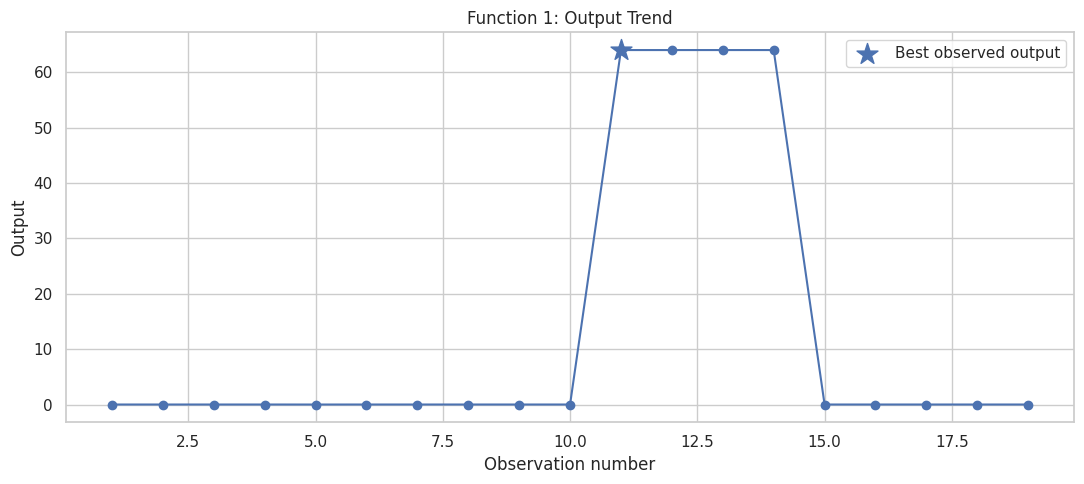

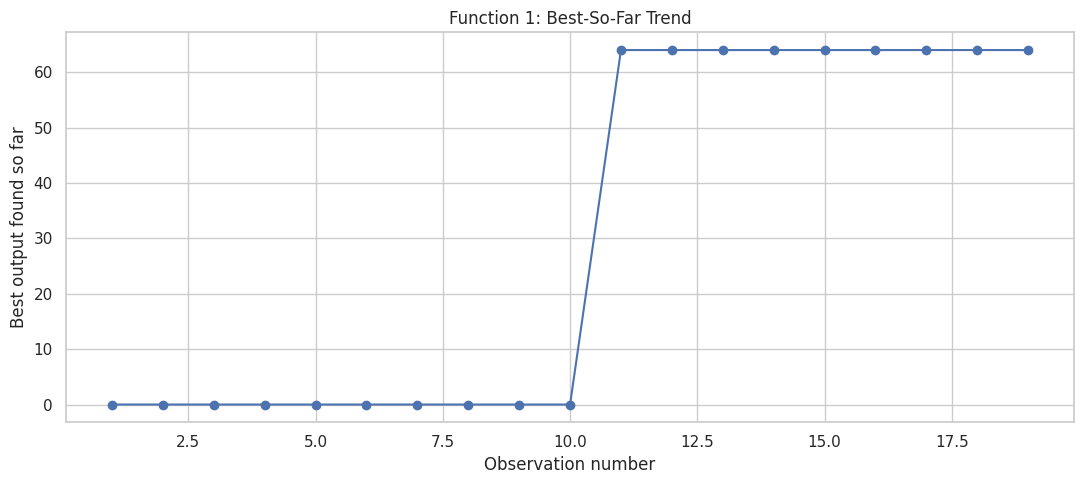

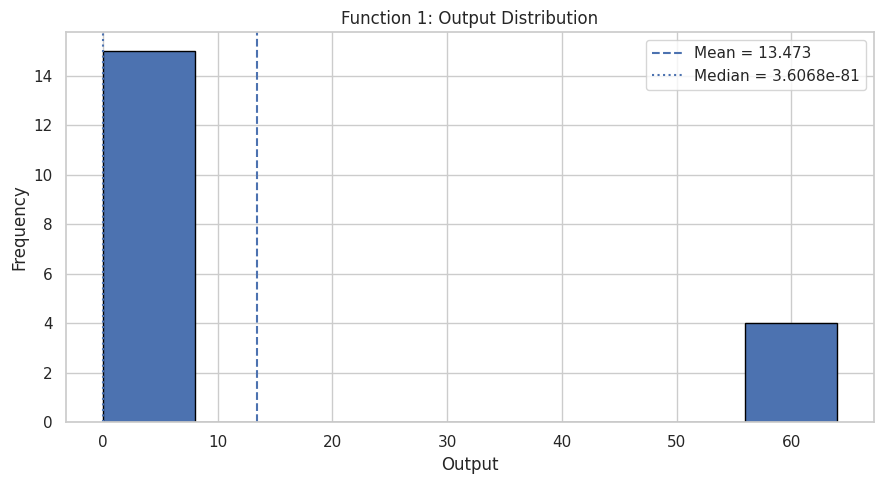

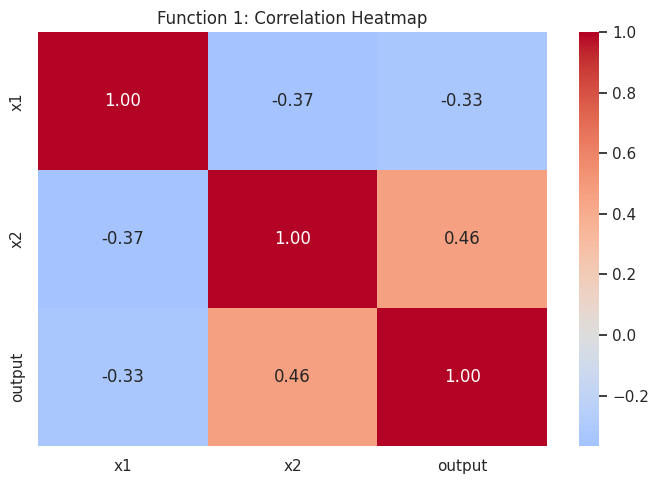

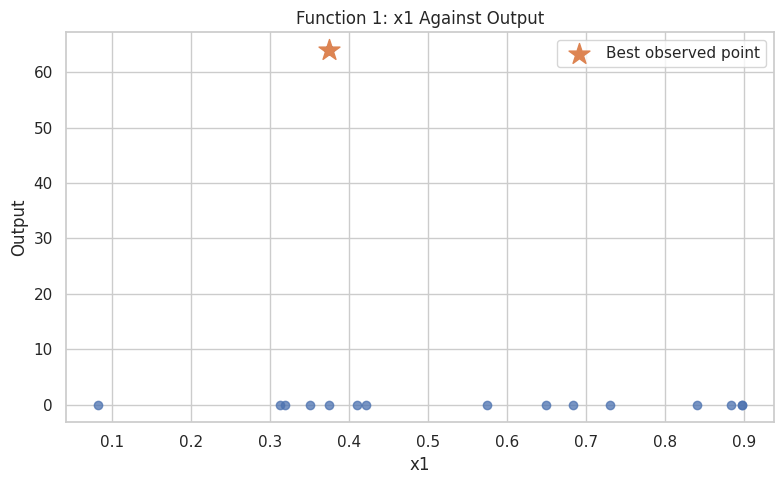

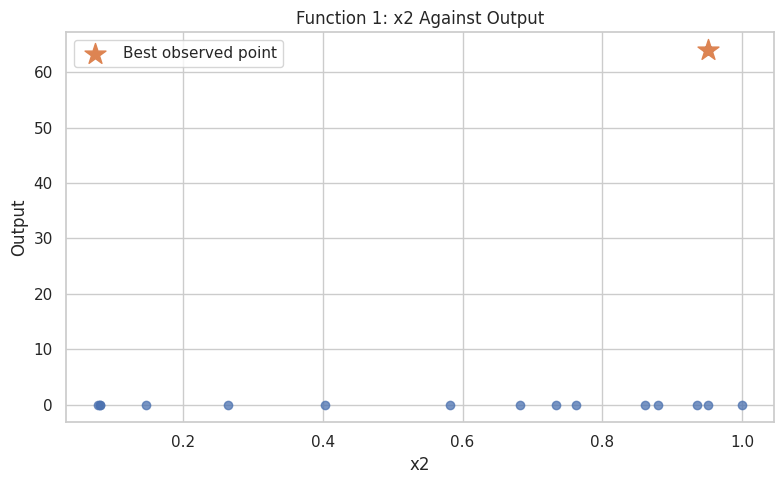


Input-output correlations
----------------------------------------
x2    0.463275
x1   -0.326300
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 19
Input dimensions   : 2
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -0.003606062644
Mean output        : 13.47349442
Median output      : 3.60677119e-81
Maximum output     : 64
Best observation   : 11
Best query point   : [0.37454  0.950714]
Best output        : 64


In [102]:
# Conduct Function 1 EDA

eda_1 = conduct_function_eda(
    function_number=1,
    dataset_folder=week_10_folder
)



FUNCTION 2 EDA

Dataset structure
----------------------------------------
Input shape : (19, 2)
Output shape: (19,)
Observations: 19
Dimensions  : 2

First five observations
----------------------------------------


,x1,x2,output
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965



Missing values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,19.0,0.493344,0.246187,0.009675,3.745400e-01,0.438166,0.621756,0.995366,0.438166,0.060608,0.292343
x2,19.0,0.603018,0.348403,0.028698,3.197302e-01,0.711120,0.950714,0.999881,0.711120,0.121385,-0.352695
output,19.0,3.516557,14.648068,-0.065624,-1.560647e-117,0.049406,0.269306,64.000000,0.049406,214.565887,4.357571



Best observed result
----------------------------------------
Best array index       : 13
Best observation number: 14
Best query point       : [0.37454  0.950714]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,output
13,0.374540,0.950714,64.000000
9,0.702637,0.926564,0.611205
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
3,0.845275,0.711120,0.293993


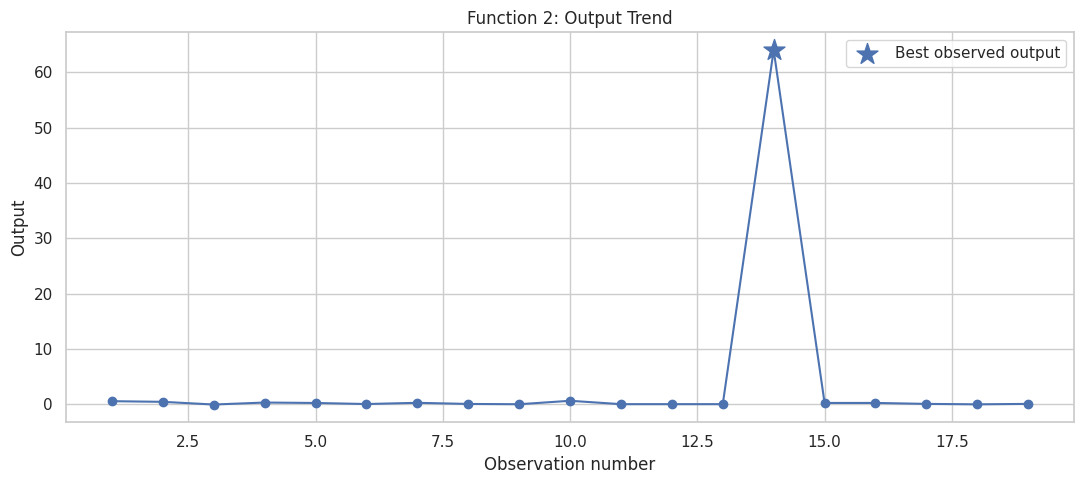

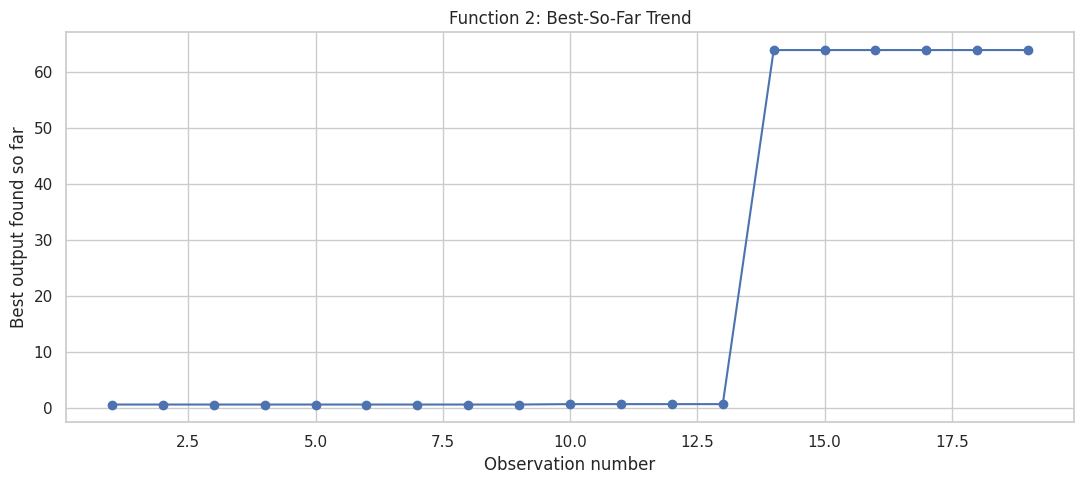

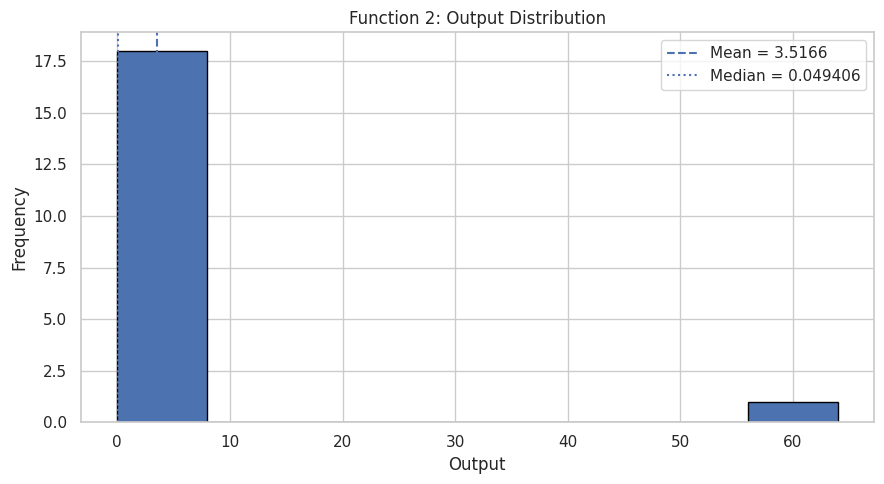

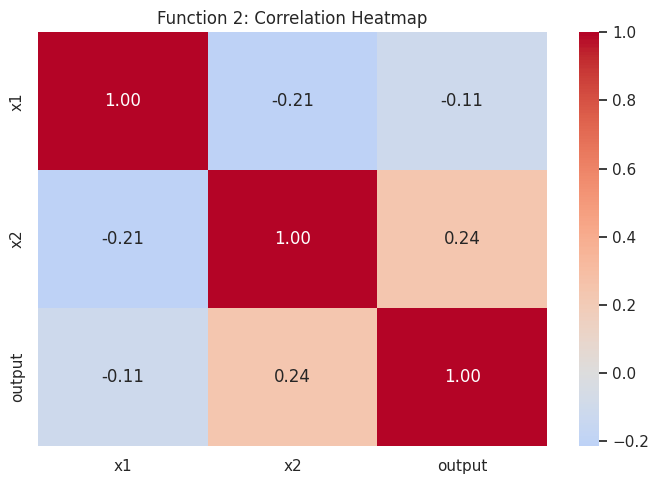

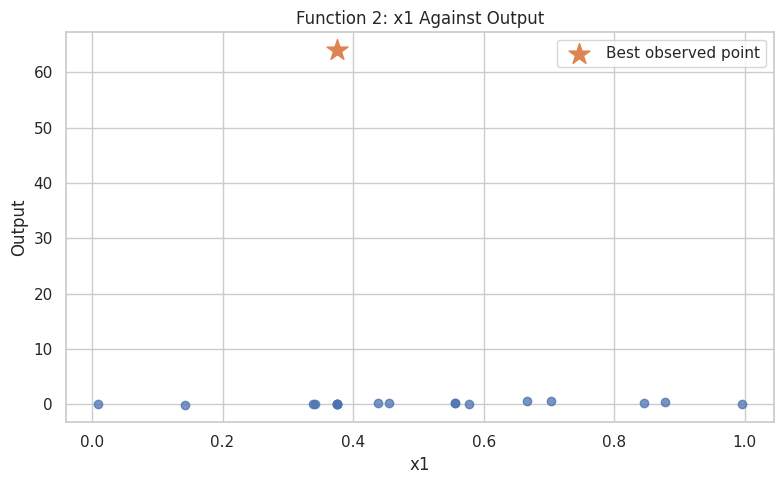

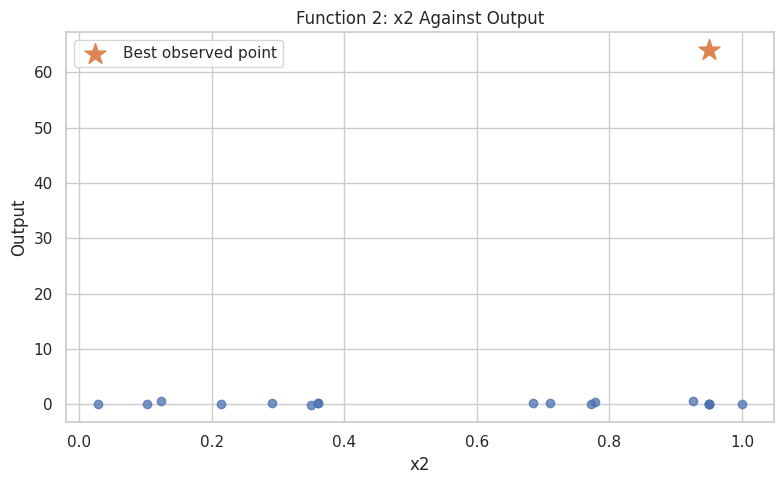


Input-output correlations
----------------------------------------
x2    0.240916
x1   -0.109159
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 19
Input dimensions   : 2
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -0.06562362444
Mean output        : 3.516557389
Median output      : 0.04940646022
Maximum output     : 64
Best observation   : 14
Best query point   : [0.37454  0.950714]
Best output        : 64


In [103]:
# Conduct Function 2 EDA
eda_2 = conduct_function_eda(
    function_number=2,
    dataset_folder=week_10_folder
)



FUNCTION 3 EDA

Dataset structure
----------------------------------------
Input shape : (24, 3)
Output shape: (24,)
Observations: 24
Dimensions  : 3

First five observations
----------------------------------------


,x1,x2,x3,output
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008



Missing values
----------------------------------------
x1        0
x2        0
x3        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,24.0,0.428308,0.217105,0.046809,0.236723,0.444444,0.525760,0.965995,0.444444,0.047134,0.313629
x2,24.0,0.525585,0.235759,0.090709,0.332394,0.654168,0.667452,0.941360,0.654168,0.055582,-0.388644
x3,24.0,0.385230,0.225341,0.066089,0.264207,0.333333,0.451367,0.990882,0.333333,0.050779,1.533347
output,24.0,10.587822,24.400507,-0.398926,-0.110819,-0.057397,-0.039775,64.000000,-0.057397,595.384726,1.910352



Best observed result
----------------------------------------
Best array index       : 15
Best observation number: 16
Best query point       : [0.444444 0.666666 0.333333]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,output
16,0.444444,0.666666,0.333333,64.000000
17,0.444444,0.666666,0.333333,64.000000
18,0.444444,0.666666,0.333333,64.000000
15,0.444444,0.666666,0.333333,64.000000
3,0.492581,0.611593,0.340176,-0.034835


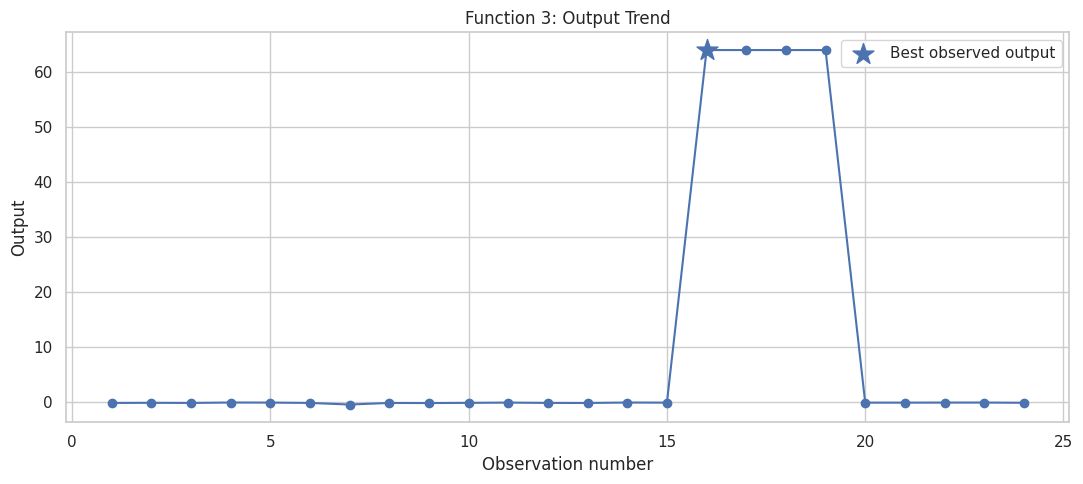

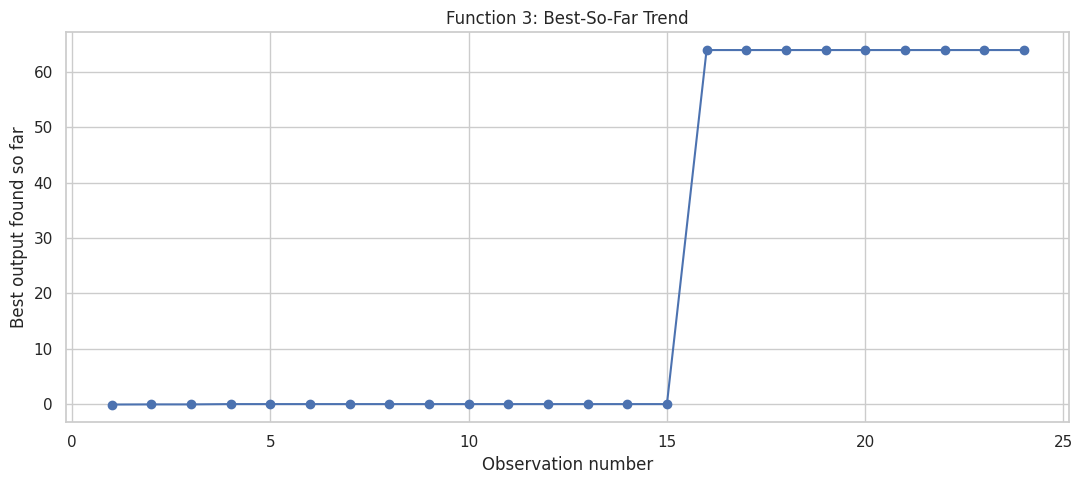

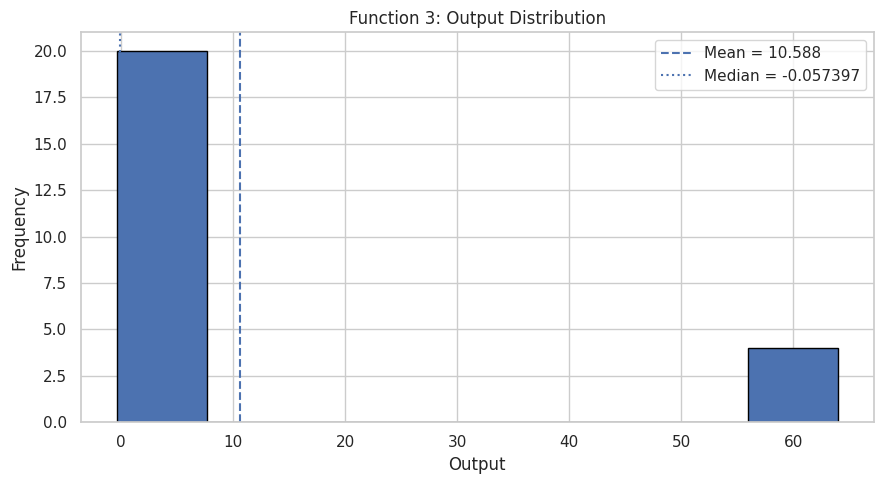

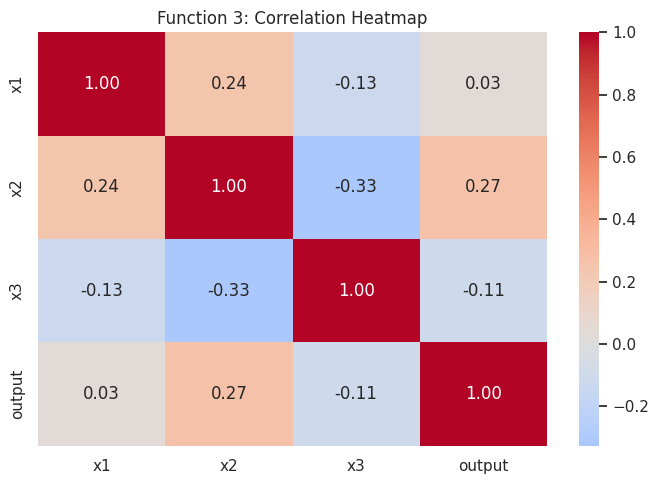

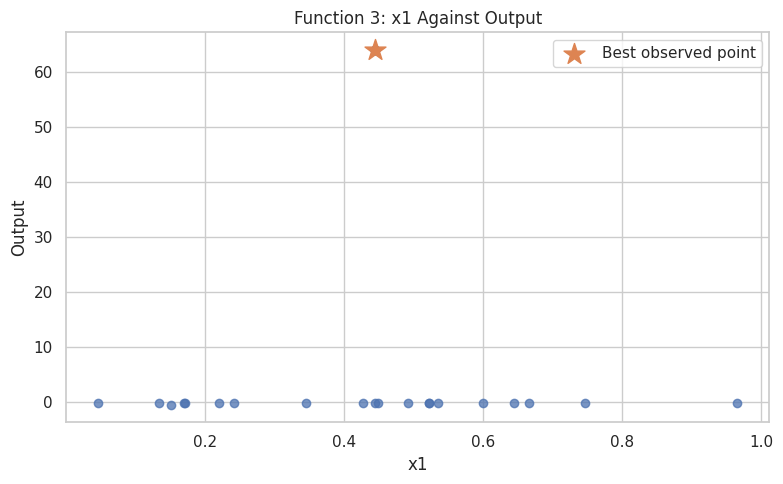

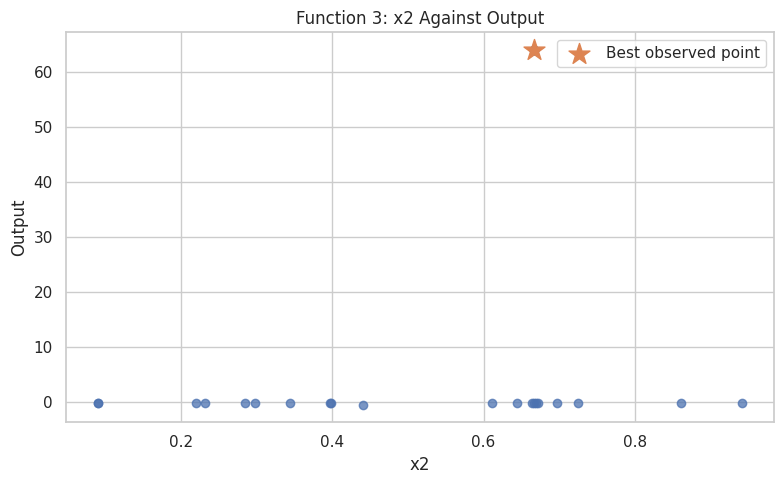

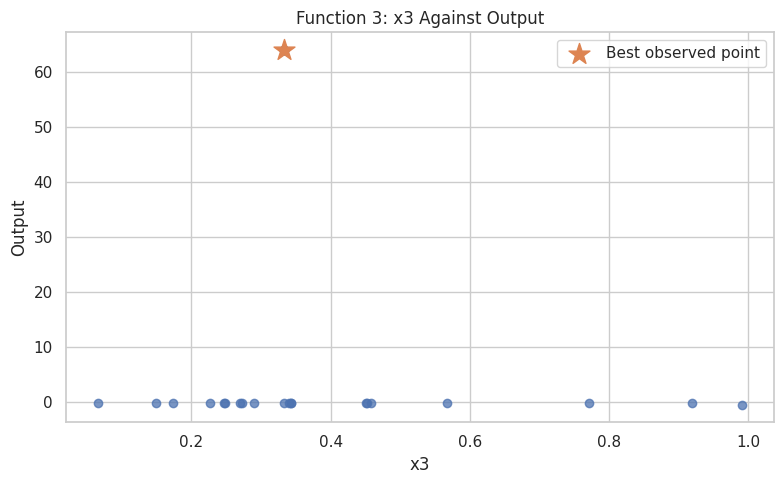


Input-output correlations
----------------------------------------
x2    0.273603
x3   -0.106818
x1    0.034740
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 24
Input dimensions   : 3
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -0.3989255131
Mean output        : 10.58782154
Median output      : -0.05739710167
Maximum output     : 64
Best observation   : 16
Best query point   : [0.444444 0.666666 0.333333]
Best output        : 64


In [104]:
# Conduct Function 3 EDA
eda_3 = conduct_function_eda(
    function_number=3,
    dataset_folder=week_10_folder
)



FUNCTION 4 EDA

Dataset structure
----------------------------------------
Input shape : (39, 4)
Output shape: (39,)
Observations: 39
Dimensions  : 4

First five observations
----------------------------------------


,x1,x2,x3,x4,output
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,39.0,0.550692,0.275463,0.037825,0.304107,0.555555,0.742658,0.985622,0.555555,0.075880,-0.203872
x2,39.0,0.434988,0.294013,0.002958,0.155668,0.444444,0.665893,0.919592,0.444444,0.086444,0.032665
x3,39.0,0.399728,0.266891,0.014095,0.211689,0.369353,0.613210,0.939178,0.369353,0.071231,0.431674
x4,39.0,0.404282,0.304584,0.068347,0.111111,0.287076,0.712761,0.999483,0.287076,0.092771,0.433615
output,39.0,-13.883382,15.084695,-32.625660,-20.092676,-16.026400,-11.632837,64.000000,-16.026400,227.548015,3.706182



Best observed result
----------------------------------------
Best array index       : 33
Best observation number: 34
Best query point       : [0.555555 0.444444 0.222222 0.111111]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,output
33,0.555555,0.444444,0.222222,0.111111,64.000000
32,0.555555,0.444444,0.222222,0.111111,-0.031830
30,0.555555,0.444444,0.222222,0.111111,-0.031830
31,0.555555,0.444444,0.222222,0.111111,-0.031830
27,0.577766,0.428772,0.425826,0.249007,-4.025542


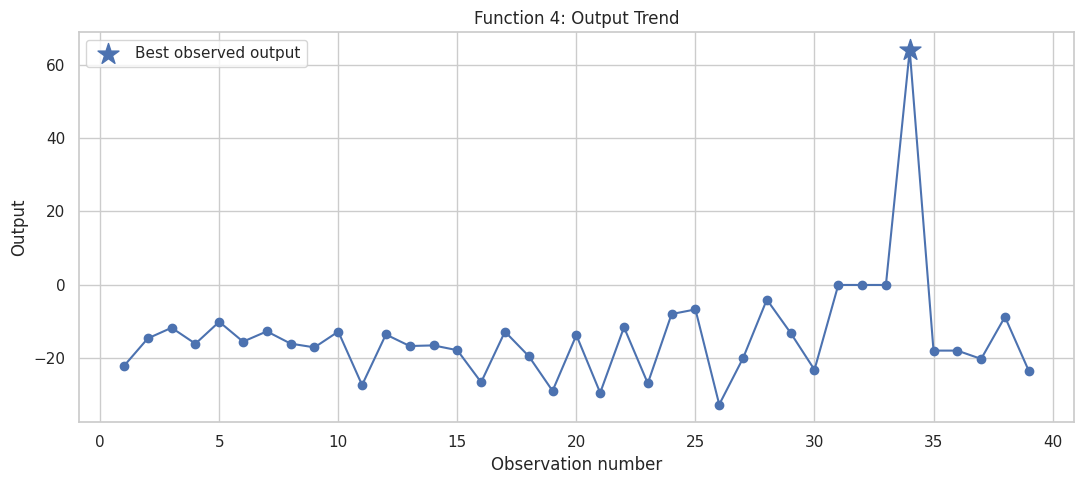

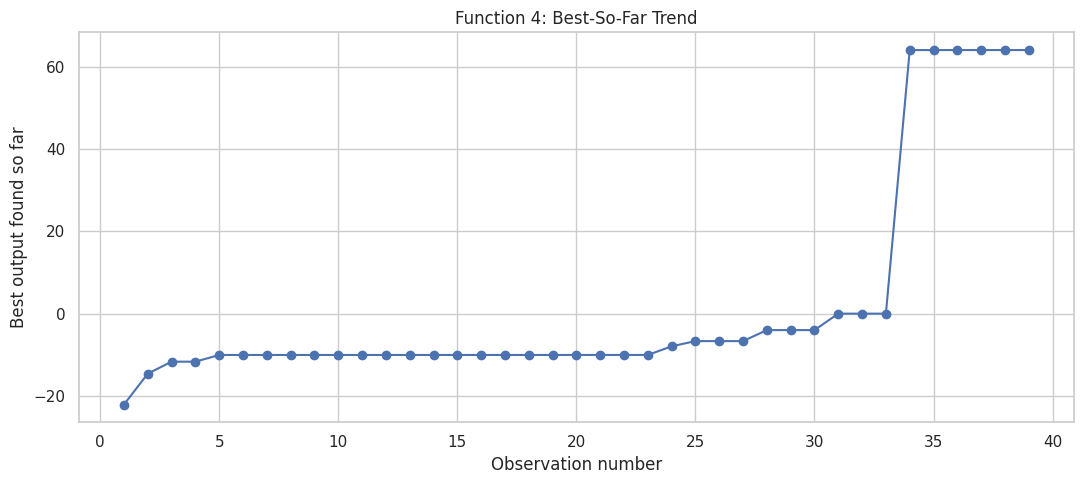

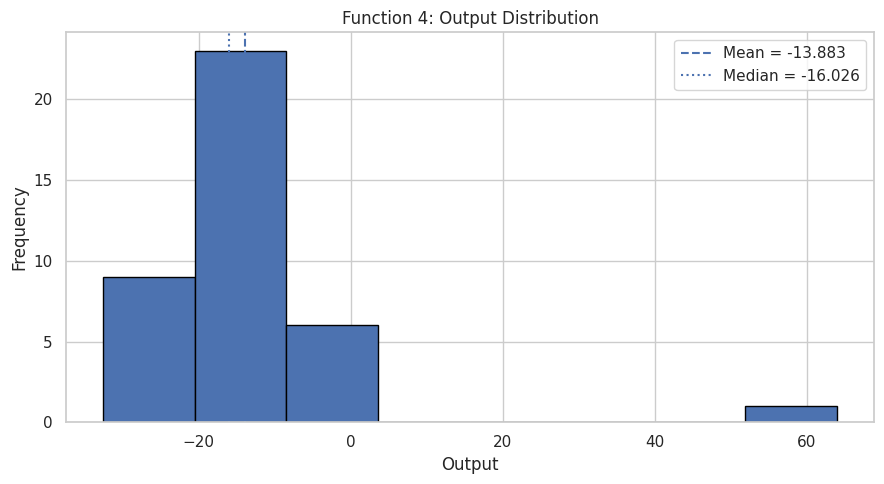

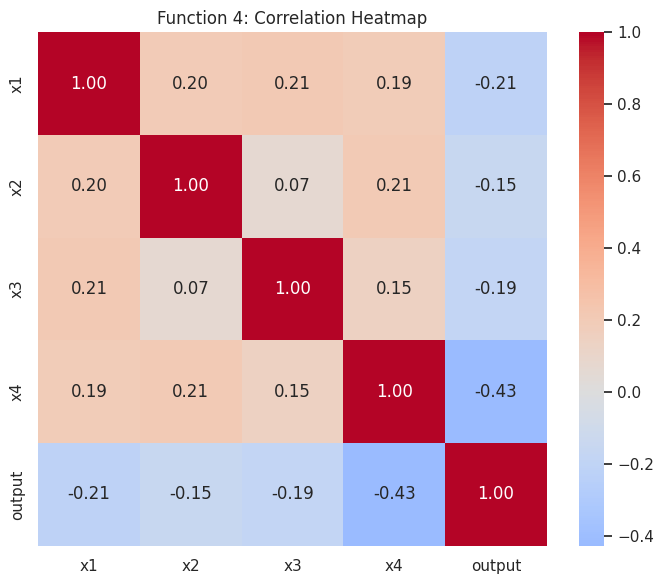

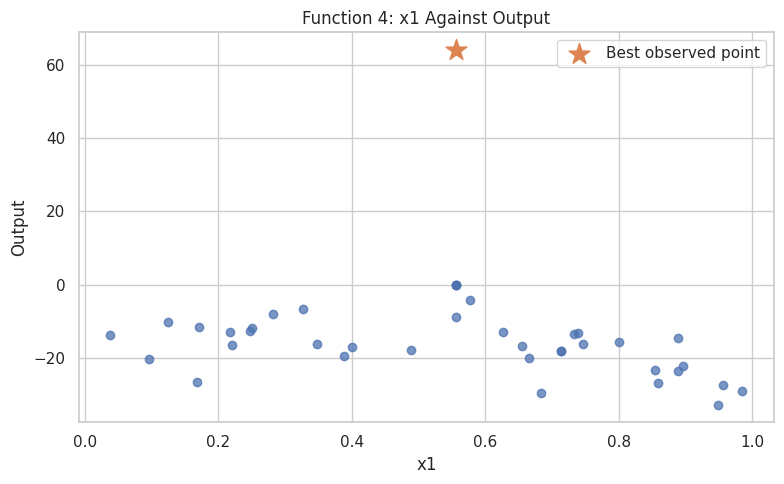

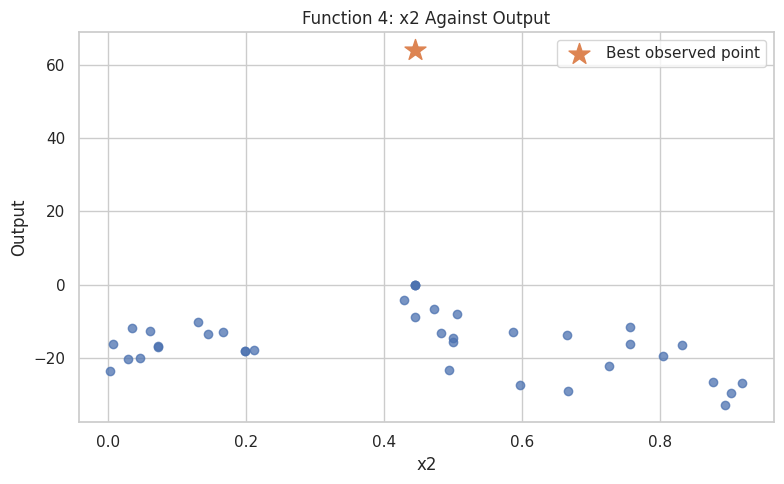

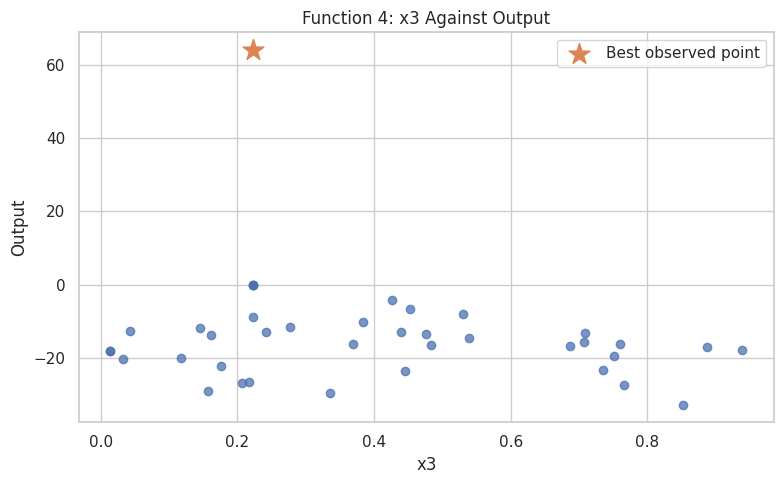

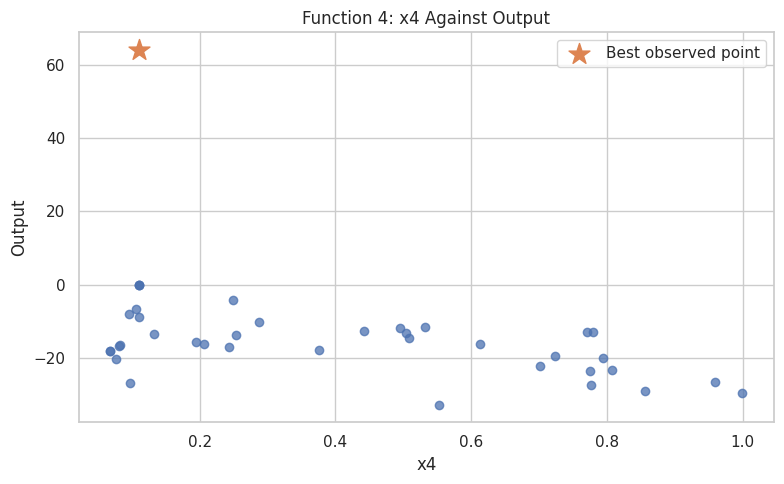


Input-output correlations
----------------------------------------
x4   -0.426794
x1   -0.209910
x3   -0.185362
x2   -0.151095
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 39
Input dimensions   : 4
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -32.62566022
Mean output        : -13.88338194
Median output      : -16.02639977
Maximum output     : 64
Best observation   : 34
Best query point   : [0.555555 0.444444 0.222222 0.111111]
Best output        : 64


In [105]:
# Conduct Function 4 EDA
eda_4 = conduct_function_eda(
    function_number=4,
    dataset_folder=week_10_folder
)



FUNCTION 5 EDA

Dataset structure
----------------------------------------
Input shape : (29, 4)
Output shape: (29,)
Observations: 29
Dimensions  : 4

First five observations
----------------------------------------


,x1,x2,x3,x4,output
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,29.0,0.419236,0.240200,0.00000,0.224189,0.355482,0.677491,0.836478,0.355482,0.057696,0.219723
x2,29.0,0.547864,0.282661,0.00000,0.322242,0.630025,0.817957,0.862540,0.630025,0.079897,-0.555320
x3,29.0,0.525997,0.275881,0.00000,0.348097,0.479592,0.770162,0.879484,0.479592,0.076111,-0.216257
x4,29.0,0.548311,0.329040,0.00000,0.307039,0.482088,0.878515,1.000000,0.482088,0.108267,-0.184294
output,29.0,171.244720,282.057808,0.11294,24.423088,64.000000,163.122500,1088.859618,64.000000,79556.607235,2.625833



Best observed result
----------------------------------------
Best array index       : 15
Best observation number: 16
Best query point       : [0.22418902 0.84648049 0.87948418 0.87851568]
Best output value      : 1088.8596181962705

Top five observations
----------------------------------------


,x1,x2,x3,x4,output
15,0.224189,0.846480,0.879484,0.878516,1088.859618
27,0.224189,0.846480,0.879484,0.878515,1088.853511
18,0.119879,0.862540,0.643331,0.849804,431.612757
28,0.319924,0.675406,0.431628,1.000000,430.803125
14,0.438933,0.774092,0.378167,0.933696,355.806818


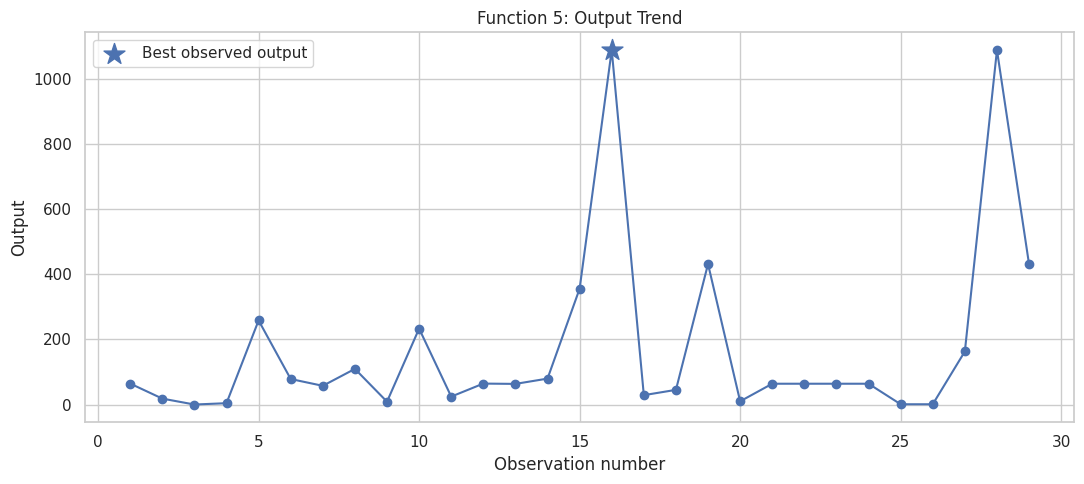

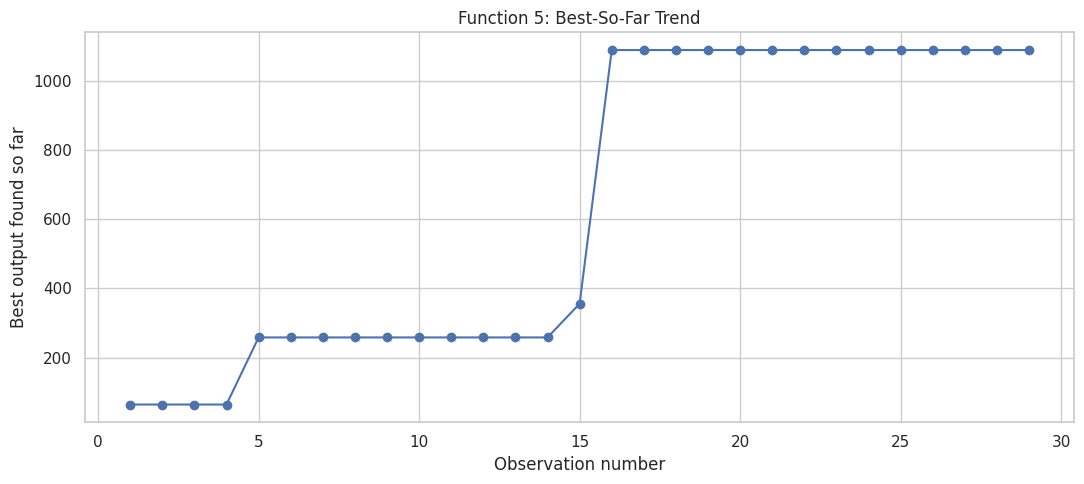

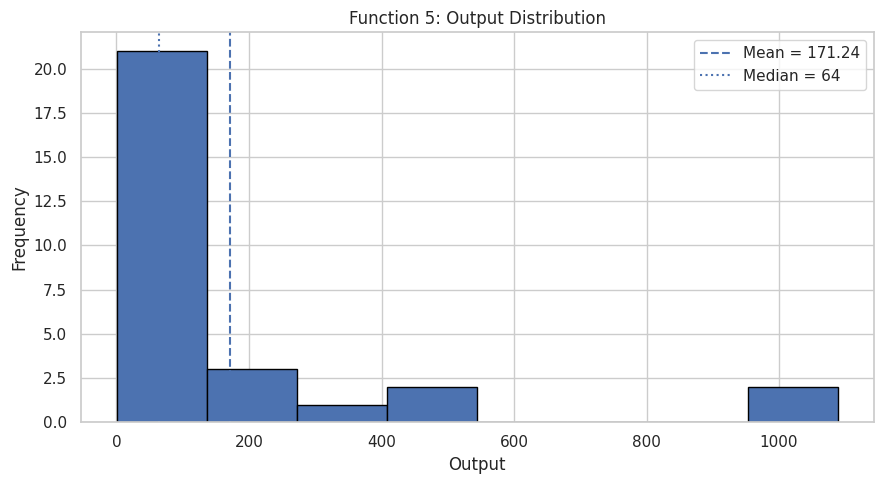

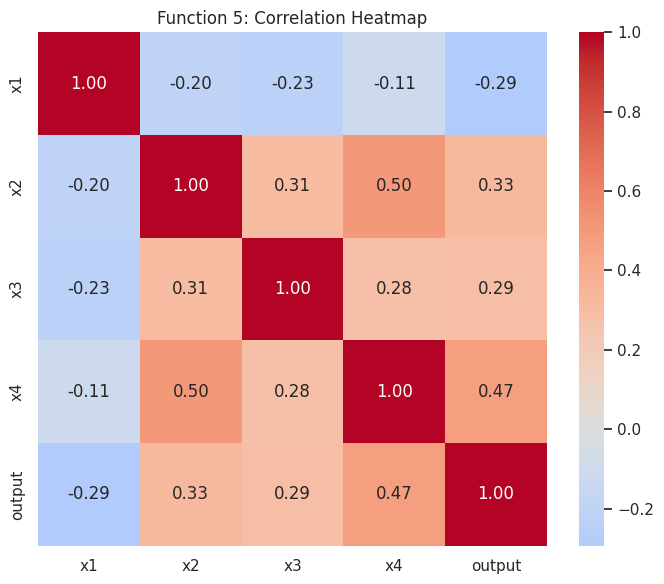

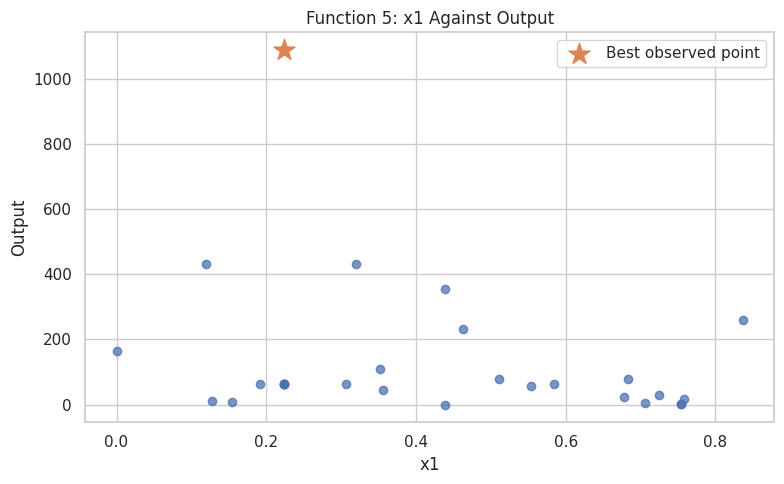

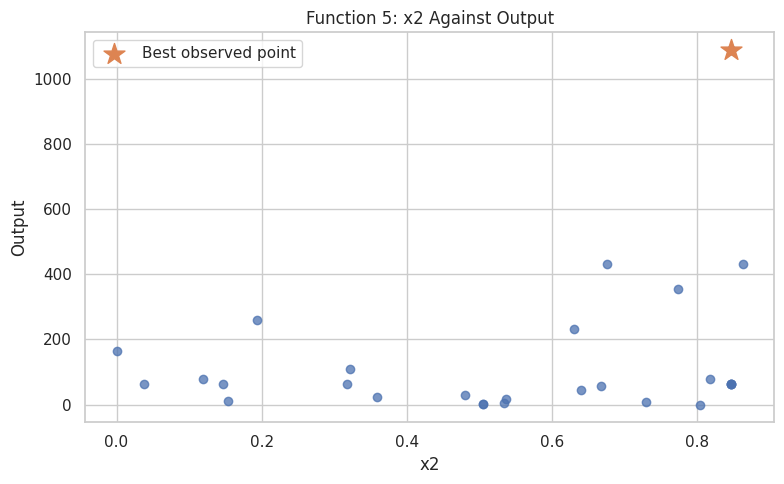

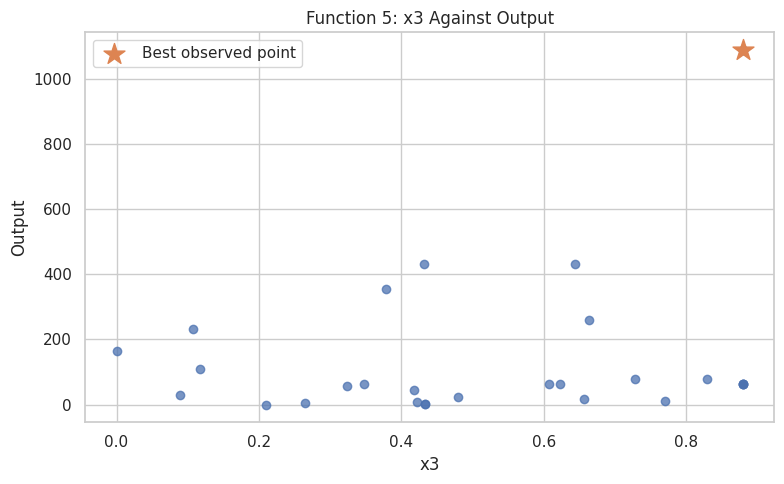

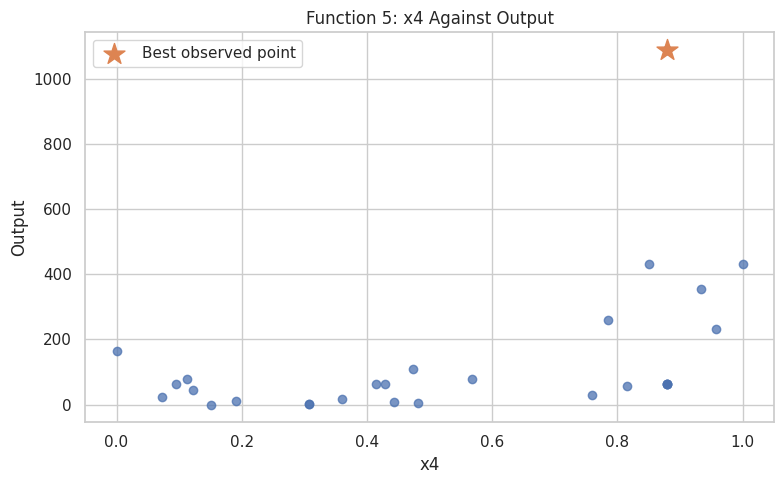


Input-output correlations
----------------------------------------
x4    0.472606
x2    0.326064
x1   -0.293955
x3    0.292514
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 29
Input dimensions   : 4
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : 0.1129397954
Mean output        : 171.2447201
Median output      : 64
Maximum output     : 1088.859618
Best observation   : 16
Best query point   : [0.22418902 0.84648049 0.87948418 0.87851568]
Best output        : 1088.859618


In [106]:
# Conduct Function 5 EDA
eda_5 = conduct_function_eda(
    function_number=5,
    dataset_folder=week_10_folder
)



FUNCTION 6 EDA

Dataset structure
----------------------------------------
Input shape : (29, 5)
Output shape: (29,)
Observations: 29
Dimensions  : 5

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,output
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,29.0,0.608287,0.267219,0.021735,0.439344,0.728186,0.770620,0.957740,0.728186,0.071406,-0.931993
x2,29.0,0.423491,0.316782,0.022732,0.154693,0.308781,0.748106,0.931871,0.308781,0.100351,0.406282
x3,29.0,0.567075,0.305258,0.016523,0.411879,0.708120,0.738396,0.978806,0.708120,0.093183,-0.625048
x4,29.0,0.540427,0.278439,0.041715,0.356552,0.680515,0.693997,0.961656,0.680515,0.077528,-0.606297
x5,29.0,0.492487,0.277110,0.004911,0.273549,0.564013,0.629310,0.897560,0.564013,0.076790,-0.409916
output,29.0,0.872410,12.159419,-2.571170,-1.702558,-1.294247,-1.144785,64.000000,-1.294247,147.851467,5.359194



Best observed result
----------------------------------------
Best array index       : 23
Best observation number: 24
Best query point       : [0.728186 0.154693 0.732552 0.693997 0.564013]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,output
23,0.728186,0.154693,0.732552,0.693997,0.564013,64.000000
22,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
21,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
20,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265


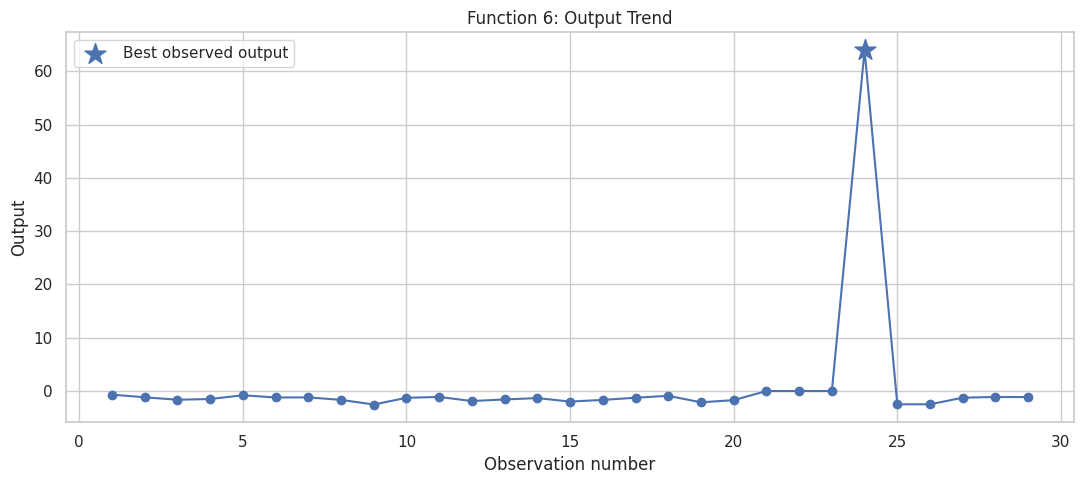

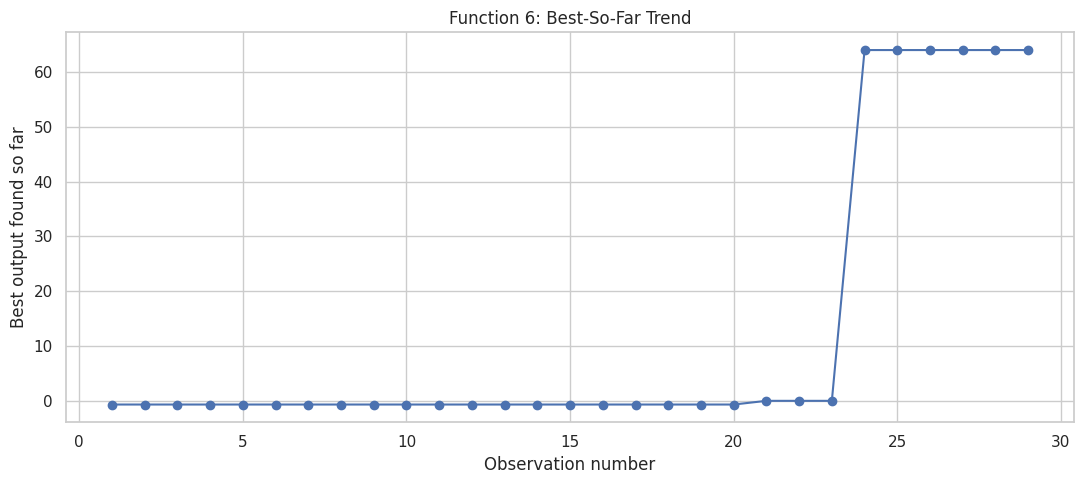

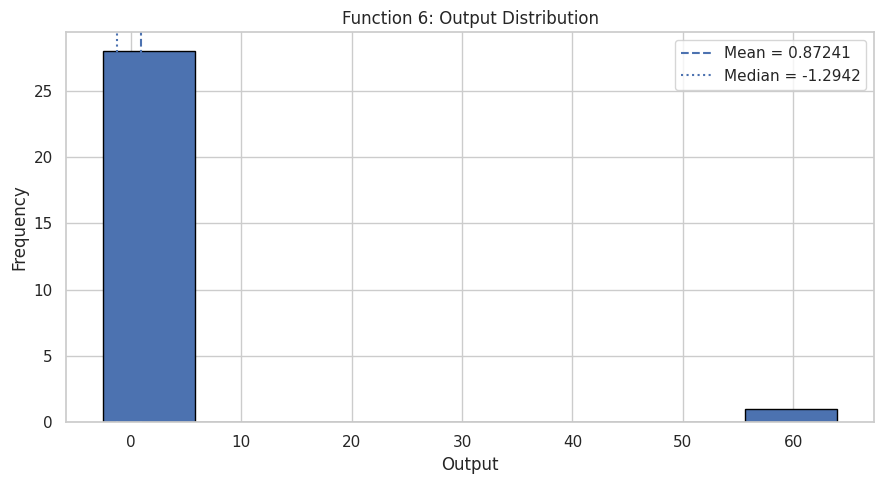

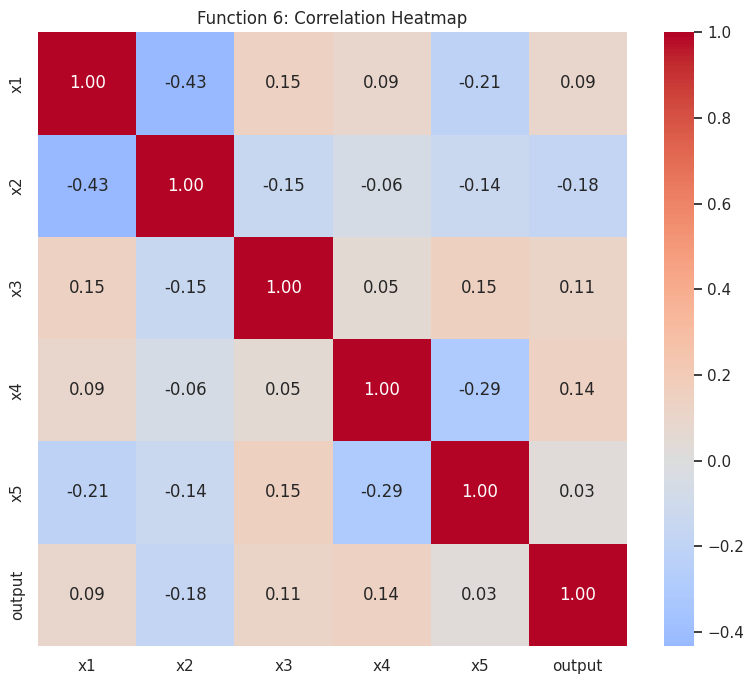

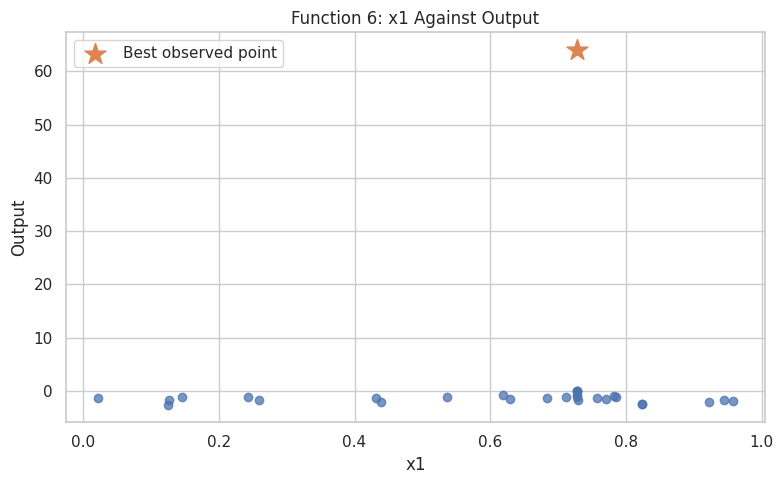

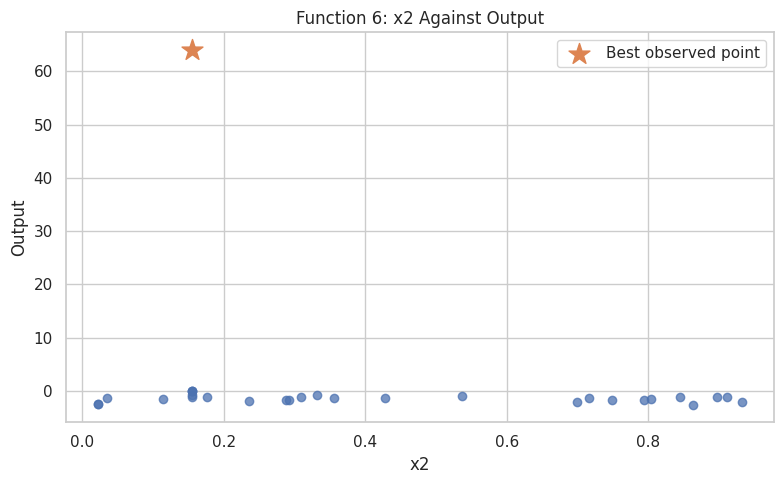

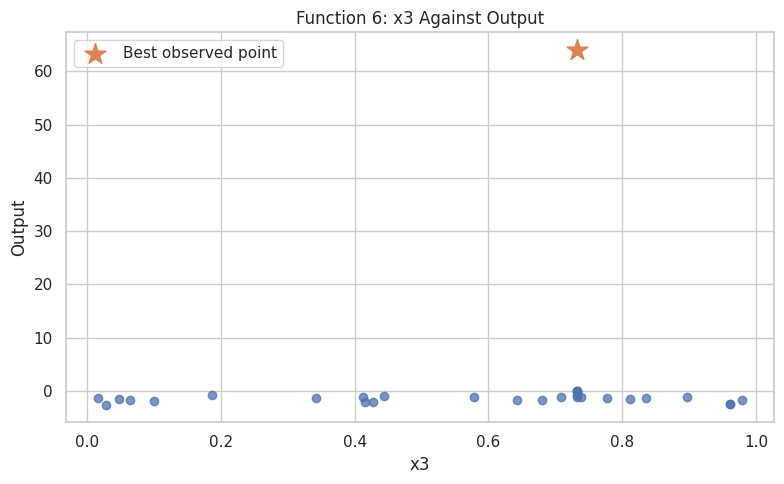

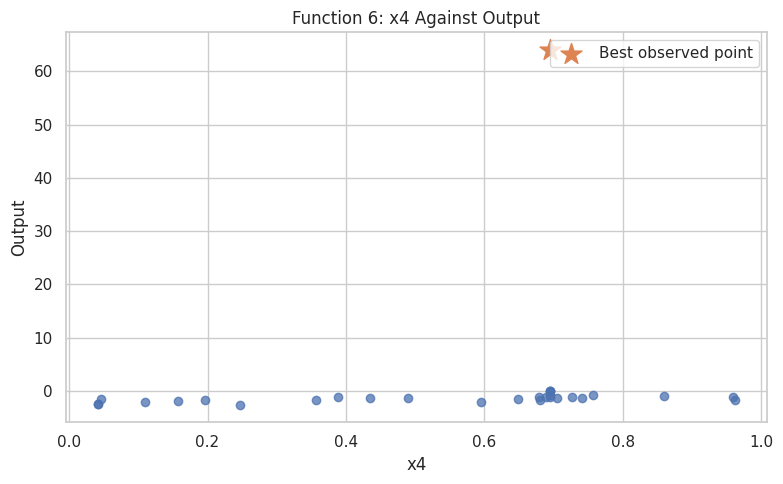

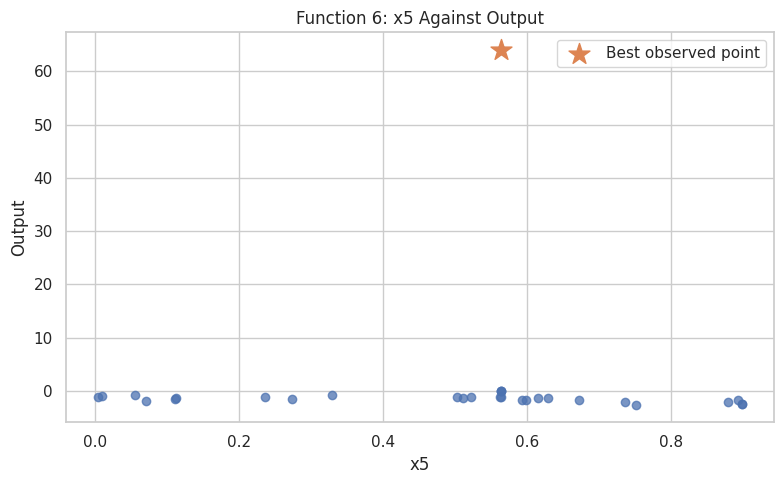


Input-output correlations
----------------------------------------
x2   -0.176378
x4    0.139228
x3    0.111763
x1    0.090932
x5    0.028784
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 29
Input dimensions   : 5
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -2.571169632
Mean output        : 0.8724104227
Median output      : -1.294246965
Maximum output     : 64
Best observation   : 24
Best query point   : [0.728186 0.154693 0.732552 0.693997 0.564013]
Best output        : 64


In [107]:
# Conduct Function 6 EDA
eda_6 = conduct_function_eda(
    function_number=6,
    dataset_folder=week_10_folder
)



FUNCTION 7 EDA

Dataset structure
----------------------------------------
Input shape : (39, 6)
Output shape: (39,)
Observations: 39
Dimensions  : 6

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,output
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,39.0,0.404319,0.330919,0.018603,0.071138,0.319810,0.724450,0.942451,0.319810,0.109507,0.260648
x2,39.0,0.446496,0.251708,0.011813,0.290003,0.491672,0.546509,0.924694,0.491672,0.063357,0.049990
x3,39.0,0.396152,0.286395,0.003635,0.189201,0.329265,0.644549,0.924571,0.329265,0.082022,0.357752
x4,39.0,0.415220,0.327070,0.037758,0.105350,0.285009,0.744094,0.961017,0.285009,0.106975,0.517307
x5,39.0,0.455914,0.276020,0.014944,0.261781,0.434667,0.687320,0.998655,0.434667,0.076187,0.259405
x6,39.0,0.511240,0.242096,0.051100,0.354190,0.614974,0.648353,0.951014,0.614974,0.058610,-0.614174
output,39.0,6.818732,19.586437,0.002701,0.027454,0.190783,0.607979,64.000000,0.190783,383.628500,2.724428



Best observed result
----------------------------------------
Best array index       : 30
Best observation number: 31
Best query point       : [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,output
33,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
32,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
31,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
30,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968


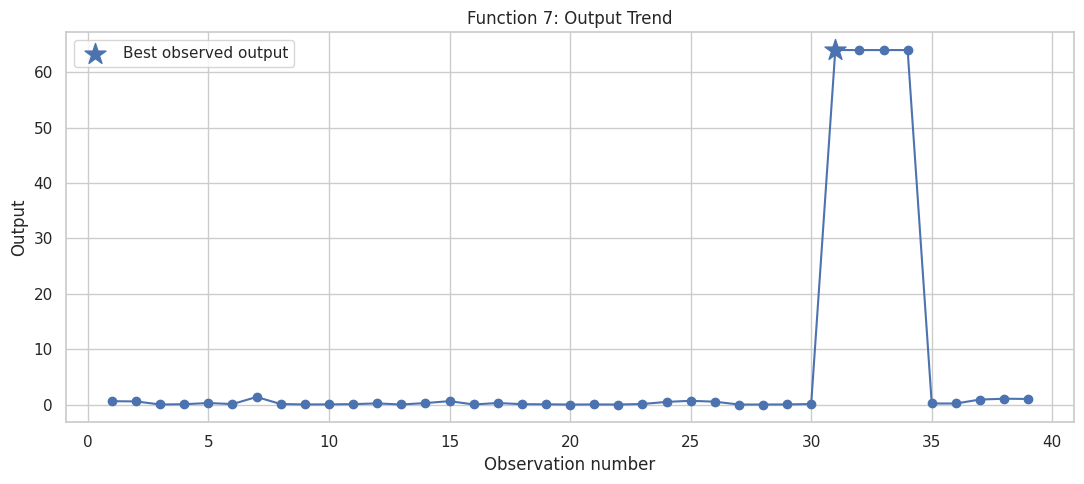

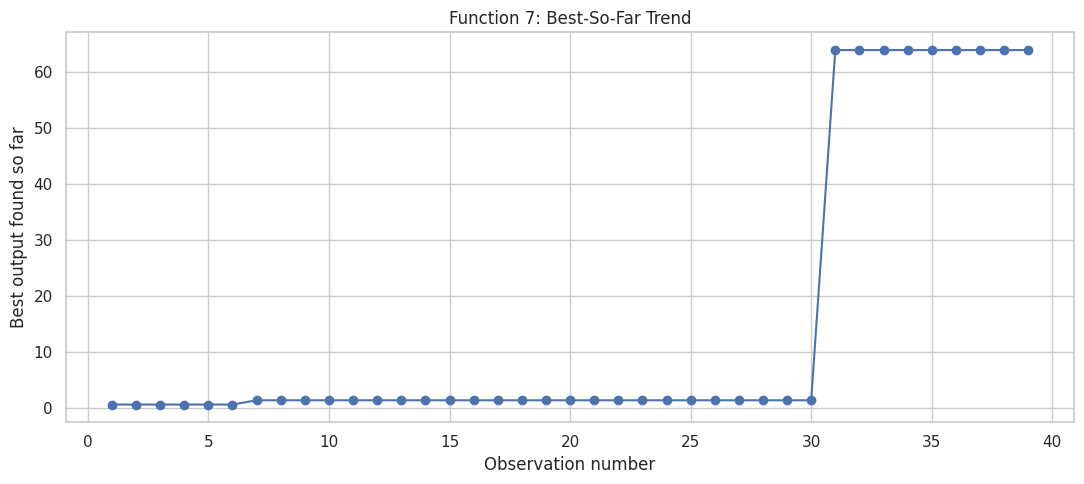

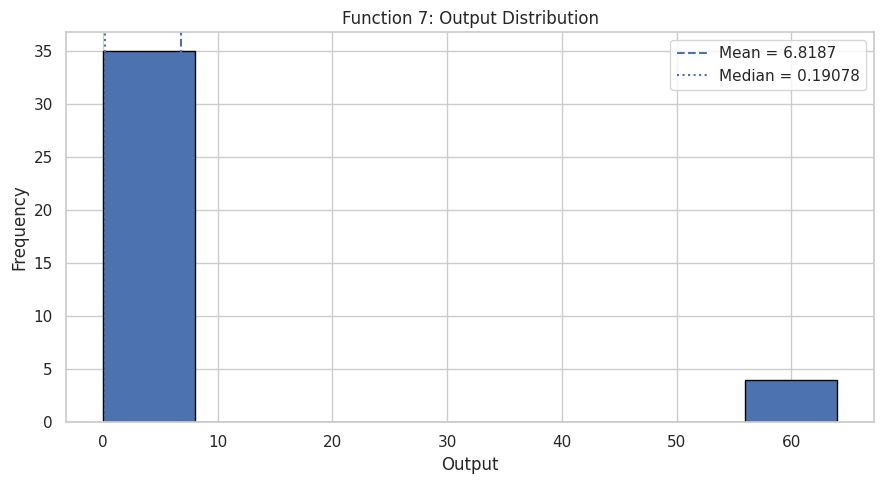

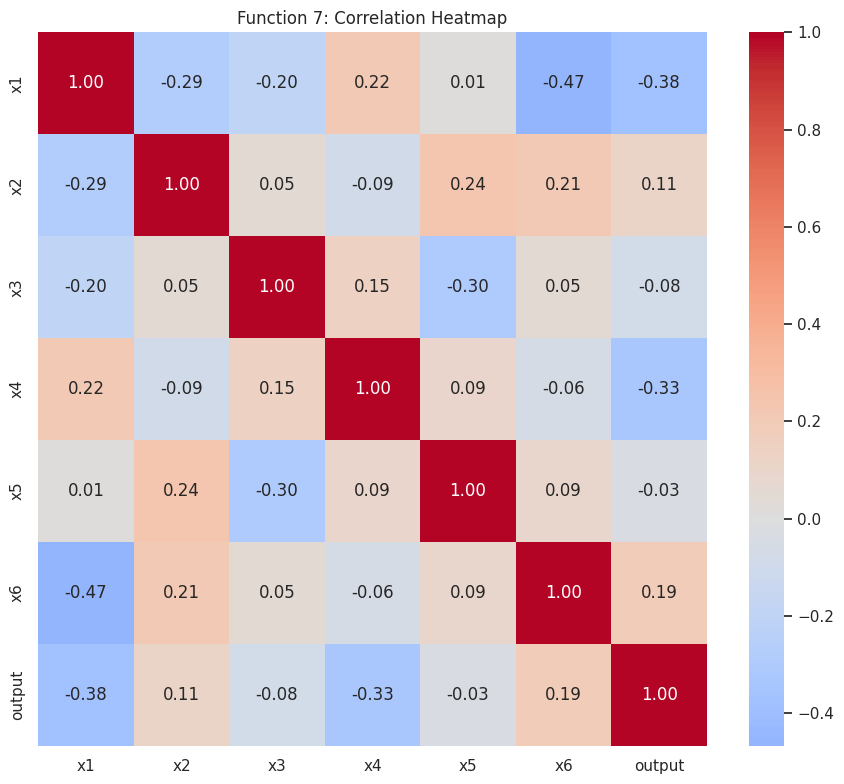

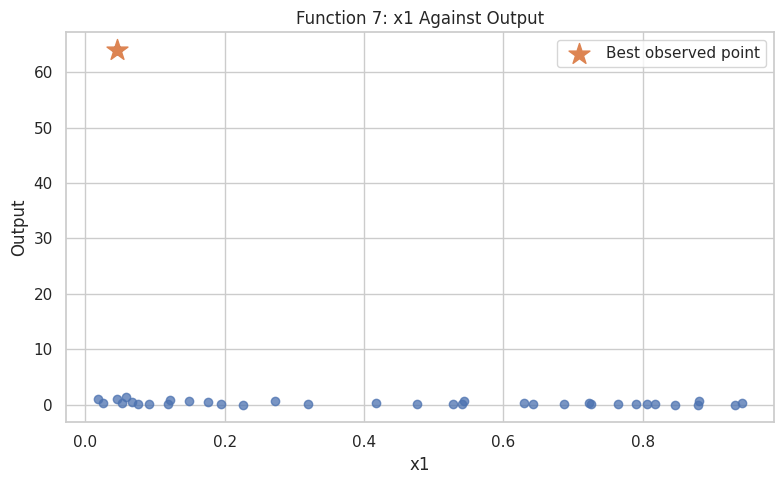

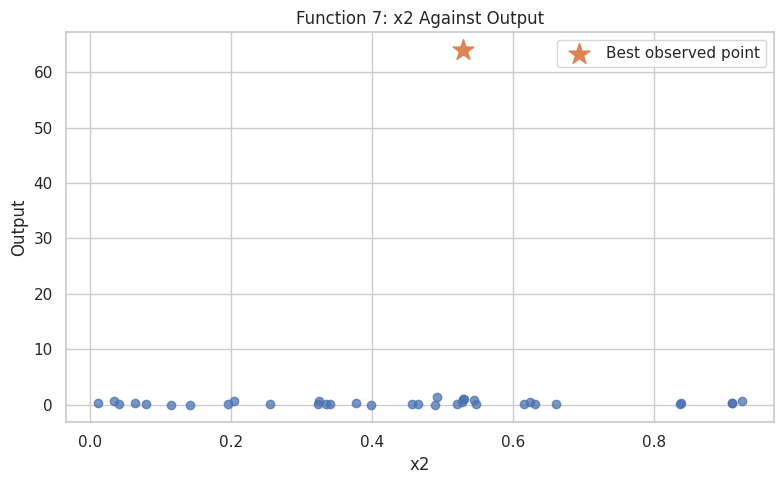

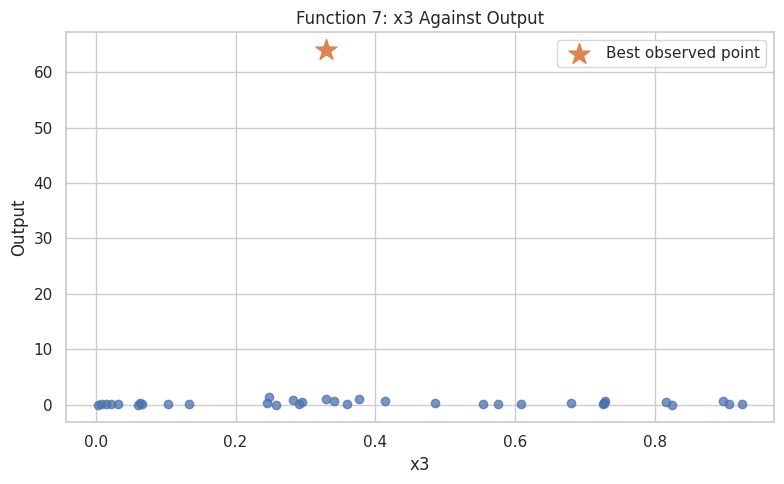

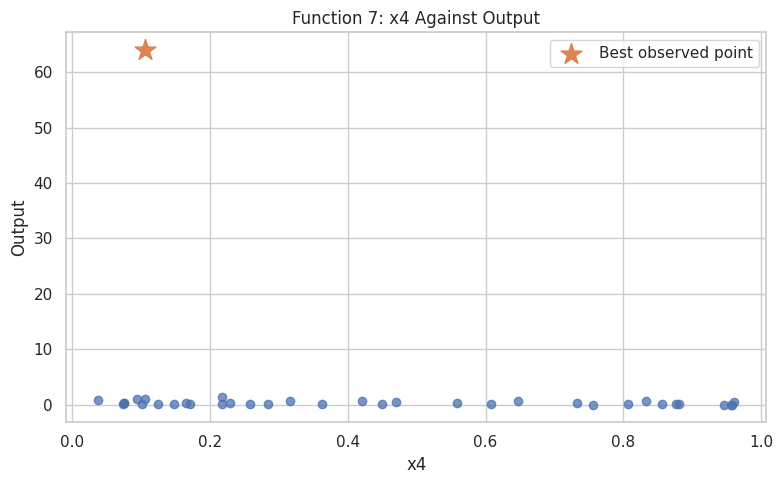

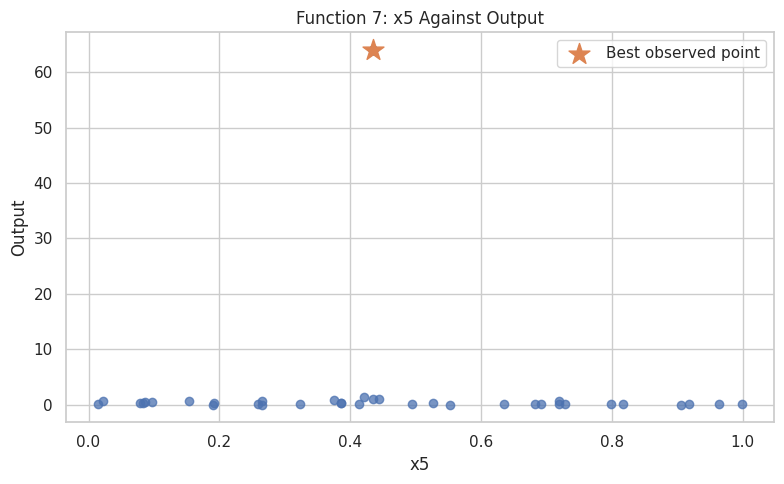

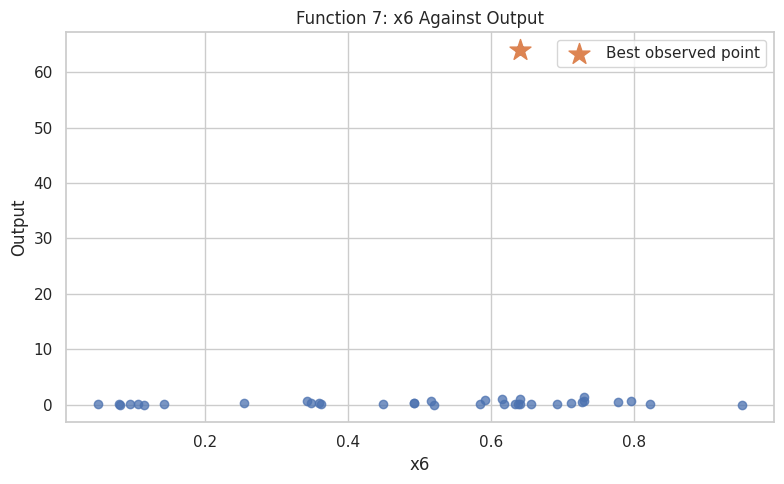


Input-output correlations
----------------------------------------
x1   -0.379020
x4   -0.328692
x6    0.189410
x2    0.113413
x3   -0.078509
x5   -0.031928
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 39
Input dimensions   : 6
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : 0.002701465025
Mean output        : 6.818732473
Median output      : 0.1907826273
Maximum output     : 64
Best observation   : 31
Best query point   : [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Best output        : 64


In [108]:
# Conduct Function 7 EDA
eda_7 = conduct_function_eda(
    function_number=7,
    dataset_folder=week_10_folder
)



FUNCTION 8 EDA

Dataset structure
----------------------------------------
Input shape : (48, 8)
Output shape: (48,)
Observations: 48
Dimensions  : 8

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,x7,x8,output
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
x7        0
x8        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
x7        0
x8        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
2

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,48.0,0.481328,0.311288,0.006802,0.253415,0.459583,0.778464,0.985945,0.459583,0.096900,0.090815
x2,48.0,0.448107,0.297951,0.003419,0.244878,0.448247,0.665174,0.973980,0.448247,0.088775,0.139591
x3,48.0,0.461263,0.310309,0.021301,0.229115,0.399460,0.728409,0.998885,0.399460,0.096292,0.252565
x4,48.0,0.395168,0.277845,0.000000,0.112338,0.406103,0.644918,0.902986,0.406103,0.077198,0.151000
x5,48.0,0.519705,0.292597,0.009649,0.259525,0.541671,0.754411,0.986902,0.541671,0.085613,-0.094815
x6,48.0,0.431795,0.278180,0.022113,0.230729,0.346254,0.667588,0.990244,0.346254,0.077384,0.494352
x7,48.0,0.511961,0.292697,0.035909,0.235962,0.555537,0.757491,0.992914,0.555537,0.085671,-0.163512
x8,48.0,0.464382,0.278034,0.041956,0.270814,0.414286,0.685055,0.988755,0.414286,0.077303,0.211680
output,48.0,8.061858,9.246363,-8.727516,7.127082,7.940817,8.658977,64.000000,7.940817,85.495233,4.516306



Best observed result
----------------------------------------
Best array index       : 43
Best observation number: 44
Best query point       : [0.273673 0.2604   0.073937 0.078562 0.862321 0.230729 0.108688 0.110992]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,x7,x8,output
43,0.273673,0.260400,0.073937,0.078562,0.862321,0.230729,0.108688,0.110992,64.000000
47,0.321258,0.232284,0.021301,0.000000,0.895967,0.249315,0.054463,0.073967,9.699892
14,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482
26,0.192640,0.630677,0.416796,0.490529,0.796086,0.654567,0.276241,0.295518,9.344274
39,0.481245,0.102461,0.219486,0.677322,0.247509,0.244341,0.163825,0.715962,9.183005


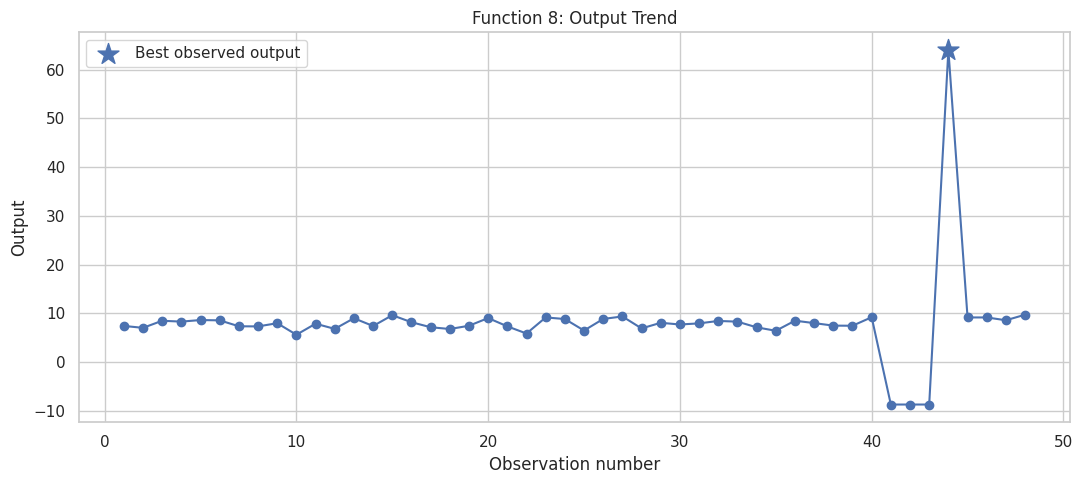

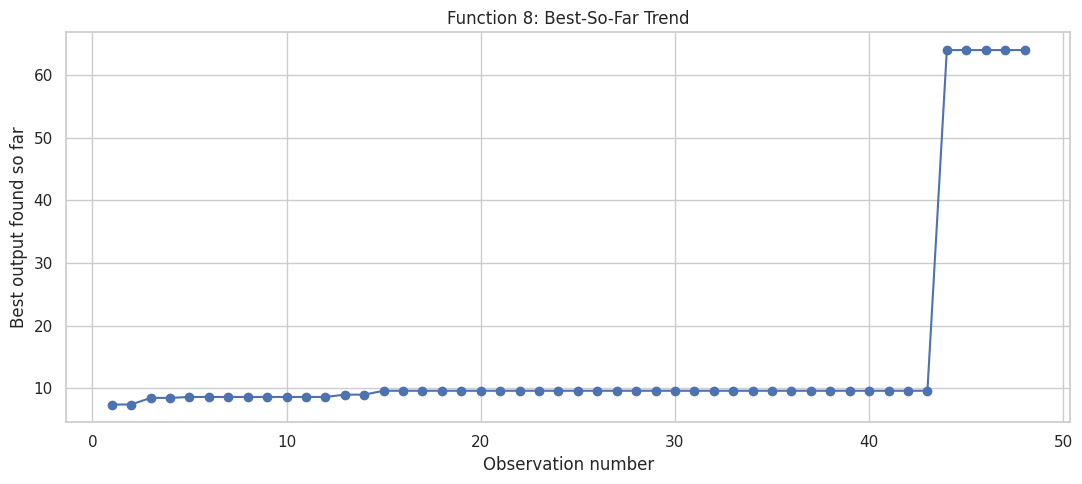

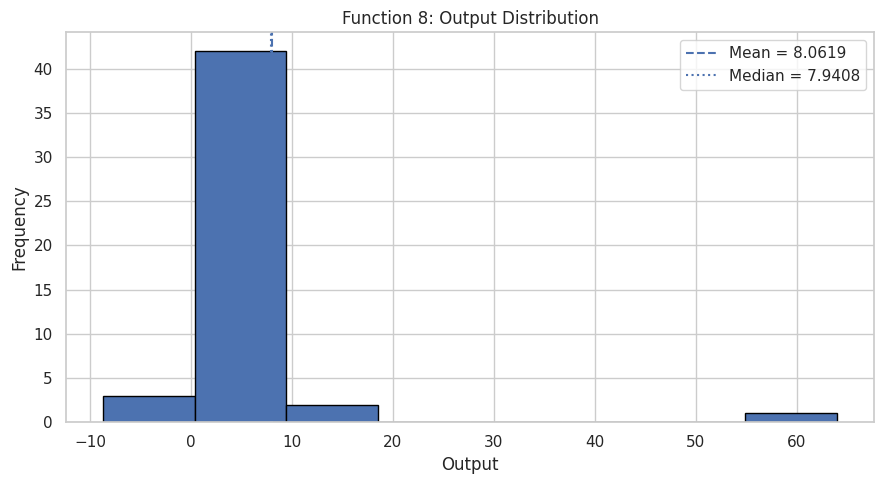

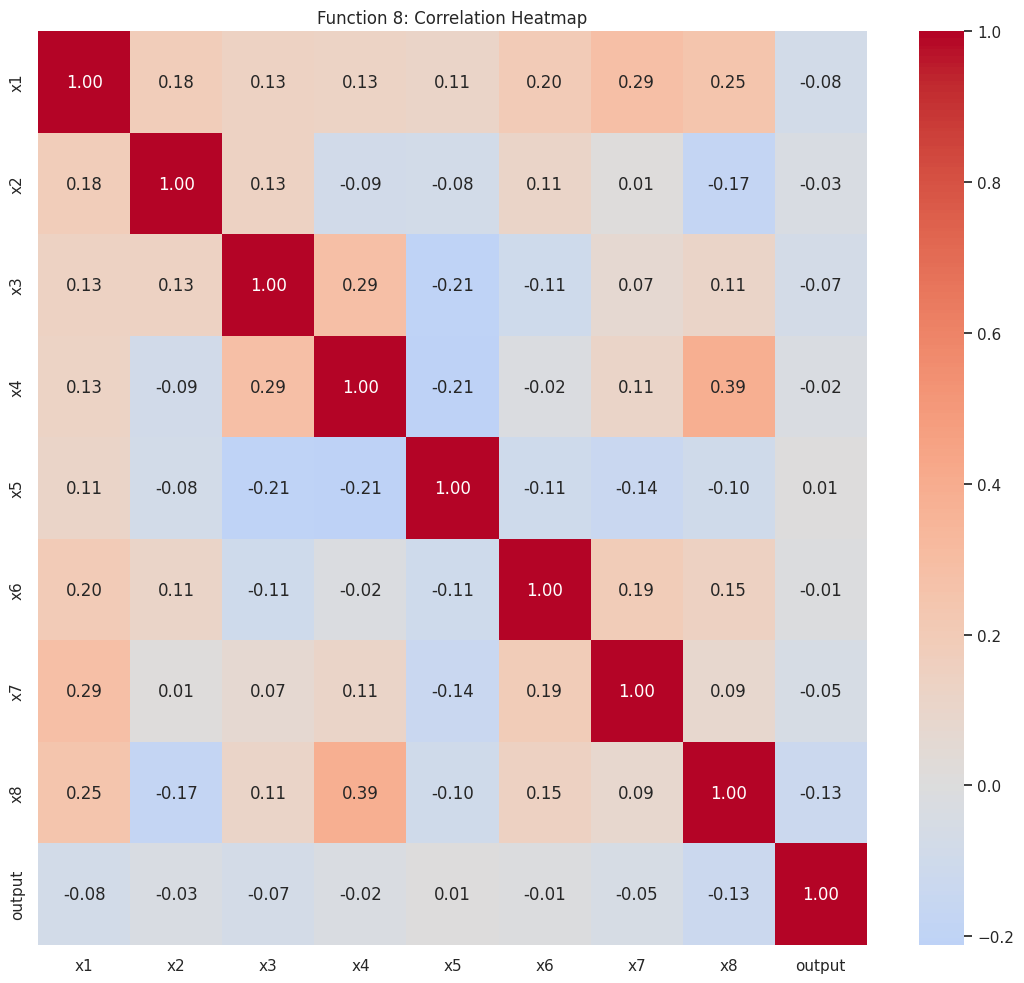

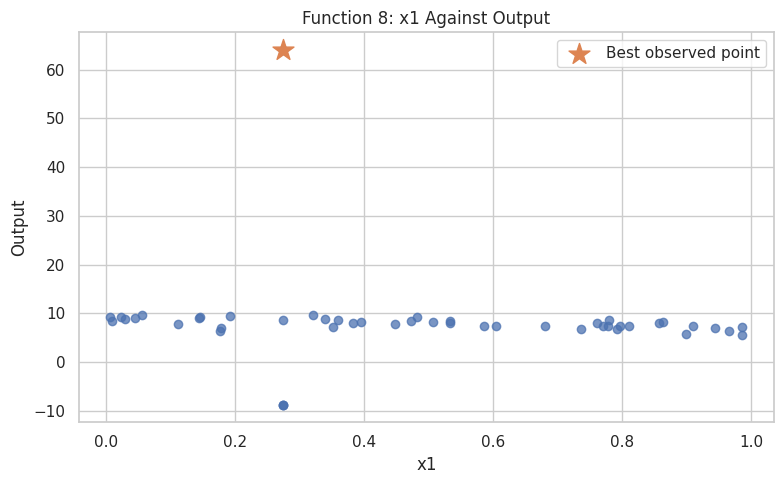

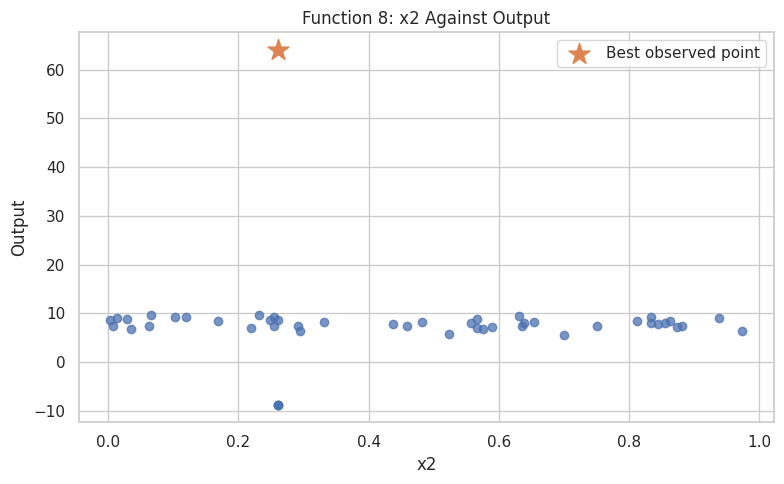

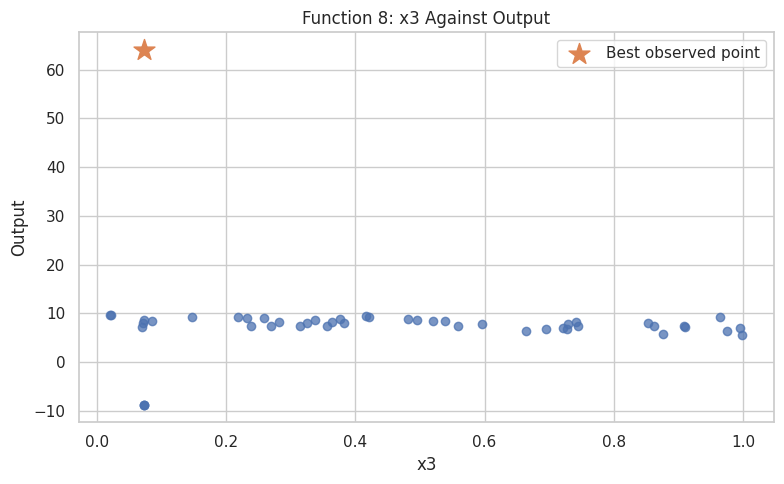

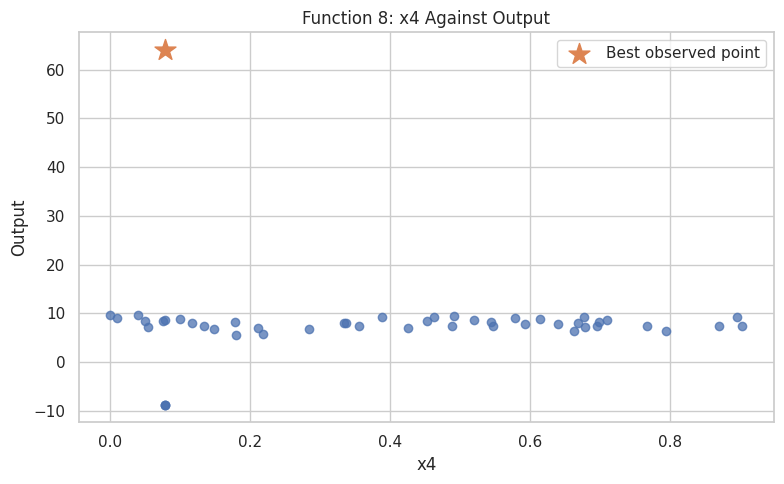

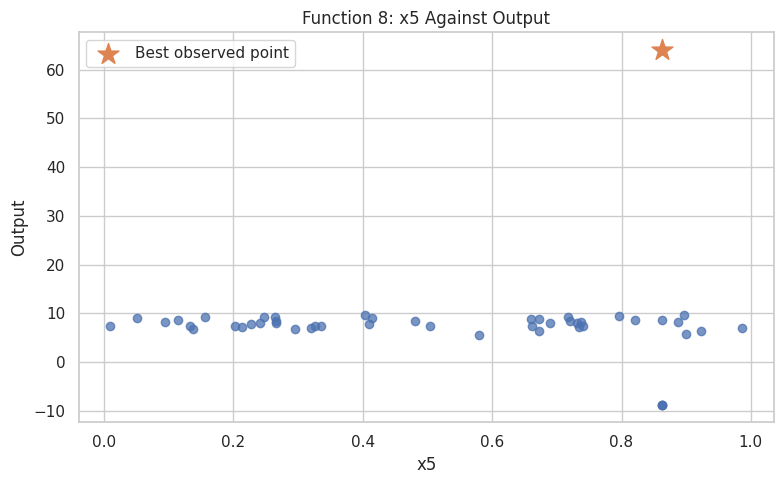

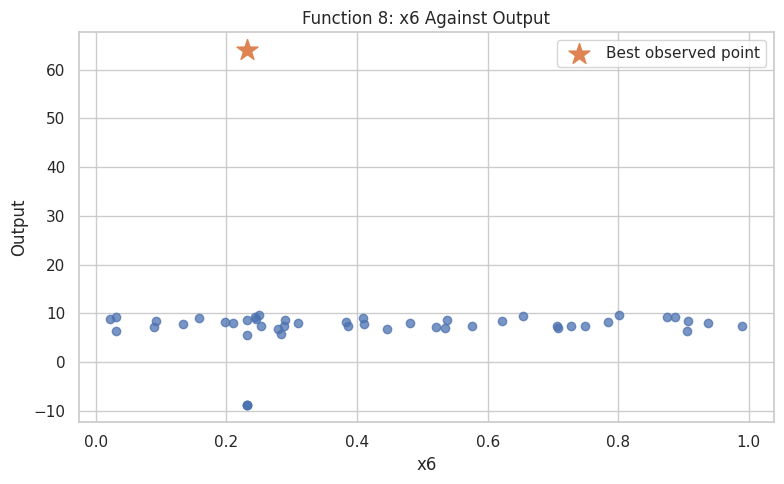

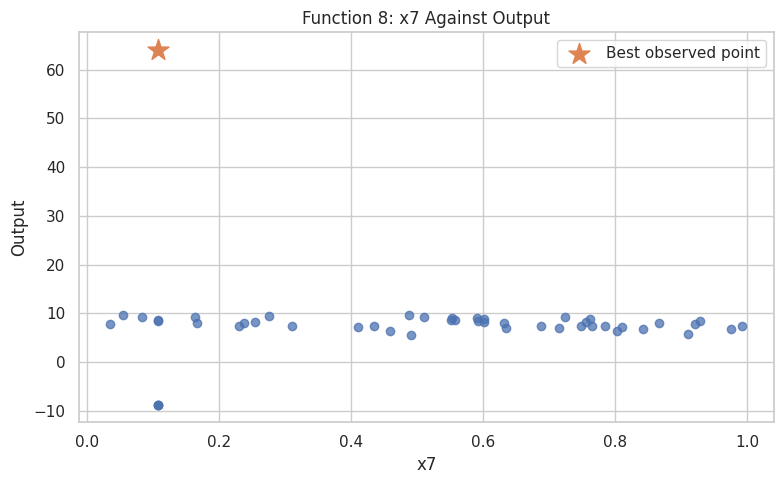

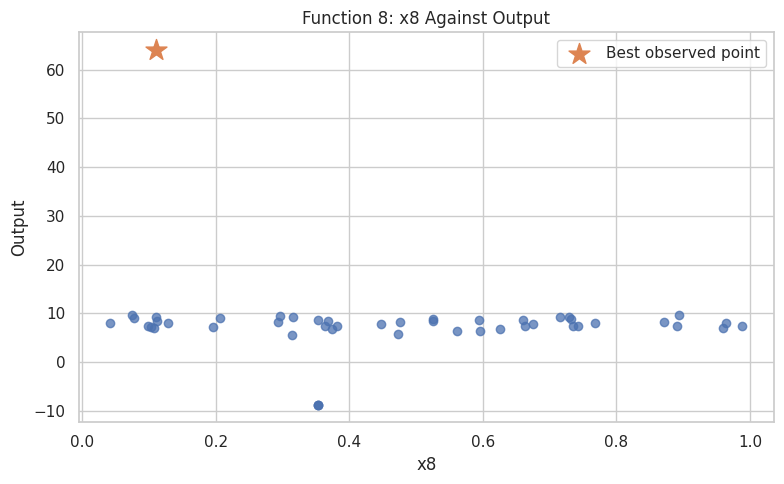


Input-output correlations
----------------------------------------
x8   -0.126036
x1   -0.076324
x3   -0.074073
x7   -0.054115
x2   -0.032815
x4   -0.024983
x5    0.010628
x6   -0.008628
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 48
Input dimensions   : 8
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 2
Minimum output     : -8.727516493
Mean output        : 8.061857881
Median output      : 7.940816757
Maximum output     : 64
Best observation   : 44
Best query point   : [0.273673 0.2604   0.073937 0.078562 0.862321 0.230729 0.108688 0.110992]
Best output        : 64


In [109]:
# Conduct Function 8 EDA
eda_8 = conduct_function_eda(
    function_number=8,
    dataset_folder=week_10_folder
)

In [110]:
all_eda_results = [
    eda_1,
    eda_2,
    eda_3,
    eda_4,
    eda_5,
    eda_6,
    eda_7,
    eda_8
]

combined_summary = []

for result in all_eda_results:

    X = result["X"]
    y = result["y"]

    combined_summary.append({
        "Function": result["function"],
        "Observations": X.shape[0],
        "Dimensions": X.shape[1],
        "Minimum_Output": np.min(y),
        "Mean_Output": np.mean(y),
        "Median_Output": np.median(y),
        "Maximum_Output": np.max(y),
        "Best_Observation": result["best_index"] + 1,
        "Best_Query_Point": result["best_input"],
        "Best_Output": result["best_output"]
    })

combined_summary_df = pd.DataFrame(combined_summary)

display(combined_summary_df)

,Function,Observations,Dimensions,Minimum_Output,Mean_Output,Median_Output,Maximum_Output,Best_Observation,Best_Query_Point,Best_Output
0,1,19,2,-0.003606,13.473494,3.606771e-81,64.000000,11,"[0.37454, 0.950714]",64.000000
1,2,19,2,-0.065624,3.516557,4.940646e-02,64.000000,14,"[0.37454, 0.950714]",64.000000
2,3,24,3,-0.398926,10.587822,-5.739710e-02,64.000000,16,"[0.444444, 0.666666, 0.333333]",64.000000
3,4,39,4,-32.625660,-13.883382,-1.602640e+01,64.000000,34,"[0.555555, 0.444444, 0.222222, 0.111111]",64.000000
4,5,29,4,0.112940,171.244720,6.400000e+01,1088.859618,16,"[0.22418902330288348, 0.8464804904862864, 0.87...",1088.859618
5,6,29,5,-2.571170,0.872410,-1.294247e+00,64.000000,24,"[0.728186, 0.154693, 0.732552, 0.693997, 0.564...",64.000000
6,7,39,6,0.002701,6.818732,1.907826e-01,64.000000,31,"[0.045091, 0.528666, 0.329265, 0.10535, 0.4346...",64.000000
7,8,48,8,-8.727516,8.061858,7.940817e+00,64.000000,44,"[0.273673, 0.2604, 0.073937, 0.078562, 0.86232...",64.000000


In [ ]:
# Import the required Gaussian Process classes.
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    Matern,
    WhiteKernel,
)


Define the UCB acquisition function

For maximisation, UCB is:

 UCB(x)=mu(x)+ kappasigma(x)

where:

* mu(x) is the GP-predicted mean;
* sigma(x) is the GP uncertainty;
* κappa controls exploration;
* a larger κappa produces more exploration;
* a smaller κappa produces more exploitation.

In [112]:
def upper_confidence_bound(mean, std, kappa=2.0):
    """
    UCB acquisition function for maximisation.
    """
    return mean + (kappa * std)

In [ ]:
def generate_bo_query(
    function_number,
    dataset_folder,
    kappa=2.0,
    number_of_candidates=100000,
    random_state=42,
):
    """Fit a GP and select a new, rounded query with UCB."""
    if function_number not in EXPECTED_DIMENSIONS:
        raise ValueError("function_number must be between 1 and 8.")
    if kappa < 0:
        raise ValueError("kappa must be non-negative.")
    if number_of_candidates < 1:
        raise ValueError("number_of_candidates must be positive.")

    input_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_inputs.npy",
    )
    output_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_outputs.npy",
    )

    X = np.asarray(np.load(input_path), dtype=float)
    y = np.asarray(np.load(output_path), dtype=float).reshape(-1)
    expected_dimension = EXPECTED_DIMENSIONS[function_number]

    if X.ndim == 1:
        if X.size % expected_dimension:
            raise ValueError(
                f"Function {function_number}: cannot reshape {X.size} input "
                f"values to dimension {expected_dimension}."
            )
        X = X.reshape(-1, expected_dimension)

    if X.ndim != 2 or X.shape[1] != expected_dimension:
        raise ValueError(
            f"Function {function_number}: expected input shape "
            f"(n, {expected_dimension}), got {X.shape}."
        )

    if X.shape[0] != y.shape[0]:
        raise ValueError(
            f"Function {function_number}: {X.shape[0]} input rows but "
            f"{y.shape[0]} outputs."
        )

    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError(
            f"Function {function_number} contains non-finite values."
        )

    if np.any((X < 0.0) | (X > 1.0)):
        raise ValueError(
            f"Function {function_number}: inputs must lie in [0, 1]."
        )

    y_mean = np.mean(y)
    y_std = np.std(y)
    y_scaled = y - y_mean if np.isclose(y_std, 0.0) else (y - y_mean) / y_std

    dimensions = X.shape[1]
    kernel = (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3),
        )
        * Matern(
            length_scale=np.full(dimensions, 0.2),
            length_scale_bounds=(0.01, 2.0),
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=1e-6,
            noise_level_bounds=(1e-10, 1e-2),
        )
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=False,
        n_restarts_optimizer=10,
        random_state=random_state,
    )
    gp.fit(X, y_scaled)

    rng = np.random.default_rng(random_state + function_number)
    candidates = rng.uniform(
        low=0.0,
        high=1.0,
        size=(number_of_candidates, dimensions),
    )

    # Exclude points that duplicate an observation after submission rounding.
    observed_points = {tuple(row) for row in np.round(X, 6)}
    rounded_candidates = np.round(candidates, 6)
    is_new = np.array(
        [tuple(row) not in observed_points for row in rounded_candidates],
        dtype=bool,
    )
    candidates = candidates[is_new]
    rounded_candidates = rounded_candidates[is_new]

    if not len(candidates):
        raise RuntimeError("No unevaluated candidate points were generated.")

    predicted_mean, predicted_std = gp.predict(candidates, return_std=True)
    ucb = upper_confidence_bound(predicted_mean, predicted_std, kappa=kappa)

    best_candidate_index = int(np.argmax(ucb))
    next_query_rounded = rounded_candidates[best_candidate_index]
    submission_query = "-".join(
        f"{value:.6f}" for value in next_query_rounded
    )

    return {
        "function": function_number,
        "query_array": next_query_rounded,
        "submission_query": submission_query,
        "predicted_mean_scaled": predicted_mean[best_candidate_index],
        "predicted_std_scaled": predicted_std[best_candidate_index],
        "ucb_value": ucb[best_candidate_index],
        "fitted_kernel": gp.kernel_,
    }


In [124]:
# Function 1 Query
week_10_folder = "/content/drive/MyDrive/week_10_dataset"

query_1 = generate_bo_query(
    function_number=1,
    dataset_folder=week_10_folder,
    kappa=2.0,
    number_of_candidates=100000,
    random_state=42
)

print("Function 1 query:")
print(query_1["submission_query"])

Function 1 query:
0.379403-0.071186


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [125]:
all_queries = {}

for function_number in range(1, 9):

    result = generate_bo_query(
        function_number=function_number,
        dataset_folder=week_10_folder,
        kappa=2.0,
        number_of_candidates=100000,
        random_state=42
    )

    all_queries[function_number] = result

    print(
        f"Function {function_number}: "
        f"{result['submission_query']}"
    )

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 1: 0.379403-0.071186


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 2: 0.329121-0.997950


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

...

Function 6: 0.853051-0.152023-0.700695-0.554516-0.611033


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: Converge

Function 7: 0.107447-0.625529-0.309529-0.130105-0.443660-0.667717


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Convergenc

Function 8: 0.546897-0.163123-0.136484-0.078398-0.771803-0.070794-0.119397-0.111488


In [126]:
# Print only the submission strings
print("WEEK 11 QUERY POINTS")
print("=" * 50)

for function_number in range(1, 9):
    print(all_queries[function_number]["submission_query"])

WEEK 11 QUERY POINTS
0.379403-0.071186
0.329121-0.997950
0.447317-0.658930-0.324854
0.587928-0.514452-0.045793-0.032616
0.005552-0.918769-0.692571-0.988052
0.853051-0.152023-0.700695-0.554516-0.611033
0.107447-0.625529-0.309529-0.130105-0.443660-0.667717
0.546897-0.163123-0.136484-0.078398-0.771803-0.070794-0.119397-0.111488


In [ ]:
submission_file = os.path.join(
    week_10_folder,
    "week_11_query_points.txt",
)

with open(submission_file, "w", encoding="utf-8") as file:
    for function_number in range(1, 9):
        query_string = all_queries[function_number]["submission_query"]
        file.write(f"Function_{function_number}:{query_string}\n")

print("Saved to:")
print(submission_file)


## Performance summary: Weeks 1–13

This evidence table tracks optimisation performance for Functions 1–8. Values are calculated only from confirmed weekly datasets and saved query diagnostics. Missing historical diagnostics are labelled **Not recorded**, while future iterations are labelled **Pending**; no query results are reconstructed or invented. Predictive standard deviation and UCB are reported in the scaled-output units used by the GP.

In [ ]:
# Confirmed evidence sources available in this notebook.
# Add a week only after its complete dataset and query diagnostics exist.
weekly_dataset_folders = {10: week_10_folder}
weekly_query_diagnostics = {10: all_queries}

performance_columns = [
    "Week",
    "Function",
    "Observation count",
    "Previous best",
    "New observation",
    "New best",
    "Improvement",
    "Fitted GP kernel",
    "Predictive std at selected query",
    "UCB score",
    "Evidence status",
]

performance_rows = []
for week in range(1, 14):
    for function_number in range(1, 9):
        row = {column: np.nan for column in performance_columns}
        row.update({
            "Week": week,
            "Function": f"F{function_number}",
            "Fitted GP kernel": "Not recorded",
            "Evidence status": (
                "Pending" if week in {12, 13} else "Dataset not supplied"
            ),
        })

        dataset_folder = weekly_dataset_folders.get(week)
        if dataset_folder is not None:
            output_path = os.path.join(
                dataset_folder,
                f"function_{function_number}_outputs.npy",
            )
            y = np.asarray(np.load(output_path), dtype=float).reshape(-1)
            if y.size == 0 or not np.isfinite(y).all():
                raise ValueError(
                    f"Week {week}, F{function_number}: invalid outputs."
                )

            previous_best = np.max(y[:-1]) if y.size > 1 else np.nan
            new_observation = y[-1]
            new_best = np.max(y)
            improvement = (
                new_best - previous_best if y.size > 1 else np.nan
            )
            row.update({
                "Observation count": int(y.size),
                "Previous best": previous_best,
                "New observation": new_observation,
                "New best": new_best,
                "Improvement": improvement,
                "Evidence status": "Confirmed dataset",
            })

        diagnostics = weekly_query_diagnostics.get(week, {}).get(
            function_number
        )
        if diagnostics is not None:
            row.update({
                "Fitted GP kernel": str(diagnostics["fitted_kernel"]),
                "Predictive std at selected query": float(
                    diagnostics["predicted_std_scaled"]
                ),
                "UCB score": float(diagnostics["ucb_value"]),
                "Evidence status": "Confirmed dataset and GP diagnostics",
            })

        performance_rows.append(row)

performance_summary = pd.DataFrame(
    performance_rows,
    columns=performance_columns,
)
performance_summary


In [ ]:
# Save the audit table without changing any weekly datasets.
performance_summary_file = os.path.join(
    week_10_folder,
    "performance_summary_weeks_1_to_13.csv",
)
performance_summary.to_csv(performance_summary_file, index=False)
print(f"Saved performance summary to: {performance_summary_file}")


## Week 13 performance summary

This table reports F1–F8 optimisation evidence from the confirmed dataset and diagnostics retained during the original run. Missing diagnostics are labelled **Not recorded**; no historical GP model is refitted.

In [ ]:
# Reproducible performance evidence for Week 13
import os
import numpy as np
import pandas as pd

SUMMARY_WEEK = 13
SUMMARY_DATASET_FOLDER = None
SUMMARY_IS_PENDING = True

summary_columns = [
    "Week", "Function", "Observation count", "Previous best",
    "New observation", "New best", "Improvement", "Fitted GP kernel",
    "Predictive std at selected query", "UCB score", "Evidence status",
]


def _find_output_file(folder, function_number):
    candidates = [
        os.path.join(folder, f"function_{function_number}_outputs.npy"),
        os.path.join(
            folder, f"function_{function_number}", "initial_outputs.npy"
        ),
    ]
    for candidate in candidates:
        if os.path.isfile(candidate):
            return candidate
    raise FileNotFoundError(
        f"No confirmed output file found for F{function_number} in {folder}."
    )


def _recorded_gp_diagnostics(function_number):
    """Return only diagnostics already retained by the notebook."""
    diagnostic = {"kernel": "Not recorded", "std": np.nan, "ucb": np.nan}
    query_records = globals().get("all_queries")
    record = None
    if isinstance(query_records, dict):
        record = query_records.get(
            function_number,
            query_records.get(f"Function_{function_number}"),
        )
    if not isinstance(record, dict):
        candidate = globals().get(f"result_{function_number}")
        record = candidate if isinstance(candidate, dict) else None
    if isinstance(record, dict):
        kernel = record.get("fitted_kernel")
        std = record.get(
            "predicted_std_scaled",
            record.get("predicted_std", np.nan),
        )
        ucb = record.get("ucb_value", np.nan)
        if kernel is not None:
            diagnostic["kernel"] = str(kernel)
        if std is not None:
            diagnostic["std"] = float(np.asarray(std).reshape(-1)[0])
        if ucb is not None:
            diagnostic["ucb"] = float(np.asarray(ucb).reshape(-1)[0])
    gp = globals().get(f"gp_{function_number}")
    if gp is not None and hasattr(gp, "kernel_"):
        diagnostic["kernel"] = str(gp.kernel_)
    saved_std = globals().get(f"next_std_{function_number}")
    if saved_std is not None:
        diagnostic["std"] = float(np.asarray(saved_std).reshape(-1)[0])
    ucb_values = globals().get(f"ucb_{function_number}")
    selected_index = globals().get(f"next_index_{function_number}")
    if ucb_values is not None and selected_index is not None:
        diagnostic["ucb"] = float(
            np.asarray(ucb_values).reshape(-1)[int(selected_index)]
        )
    return diagnostic


performance_rows = []
for function_number in range(1, 9):
    row = {
        "Week": SUMMARY_WEEK,
        "Function": f"F{function_number}",
        "Observation count": np.nan,
        "Previous best": np.nan,
        "New observation": np.nan,
        "New best": np.nan,
        "Improvement": np.nan,
        "Fitted GP kernel": "Not recorded",
        "Predictive std at selected query": np.nan,
        "UCB score": np.nan,
        "Evidence status": "Pending",
    }
    performance_rows.append(row)

weekly_performance_summary = pd.DataFrame(
    performance_rows,
    columns=summary_columns,
)
weekly_performance_summary
